In [363]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import r2_score

In [364]:
df = pd.read_csv('Hitters.csv')
df

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,N,E,325,9,3,700.0,N
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,A,E,313,381,20,875.0,A
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,A,W,37,113,7,385.0,A
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,A,E,1314,131,12,960.0,A


In [365]:
df = df.dropna(subset=['Salary'])

# Analisis Bivariado de todas las variables y regresión univariada

bivariado de AtBat

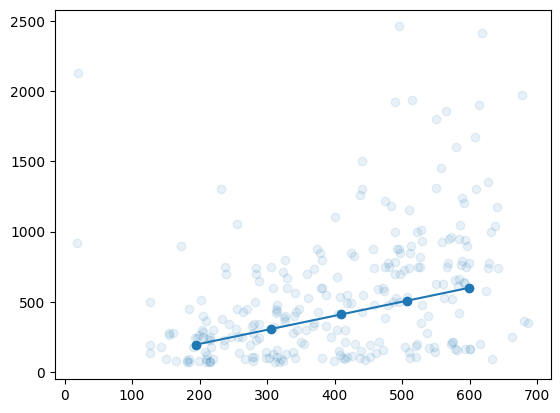

In [200]:
plt.scatter(df.AtBat, df.Salary, alpha=0.1)
df['AtBat_bin']= pd.qcut(df['AtBat'], q=5, labels=False) + 1
grouped_AtBat = df.groupby('AtBat_bin').mean(numeric_only=True)
plt.plot(grouped_AtBat.AtBat.values, grouped_AtBat.AtBat.values, marker="o")

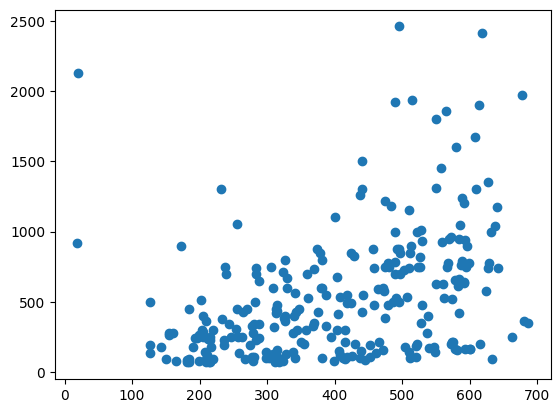

In [201]:
 # Elimina los máximos y grafica
df = df[df.AtBat != df.Salary.max()]
plt.scatter(df.AtBat, df.Salary)

In [202]:
model1 = linear_model.LinearRegression()
X = df[['AtBat']]
y = df[['Salary']]

# Fit the model to the data
model1.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model1.intercept_)
print(model1.coef_)

[47.93807428]
[[1.20896017]]


Ecuación:
$$Salary  = 47.93 + 1.20* AtBat $$

In [203]:
# Aplicando el modelo1
47.93807428 + 1.20896017 * X

,AtBat
1,428.760528
2,627.029996
3,647.582319
4,436.014289
5,766.060415
...,...
317,648.791279
318,642.746478
319,622.194155
320,740.672252


In [204]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones1 = model1.predict(X)
predicciones1

array([[428.76052705],
       [627.02999453],
       [647.58231737],
       [436.01428806],
       [766.06041379],
       [271.59570527],
       [408.2082042 ],
       [438.43220839],
       [532.73110146],
       [741.88121044],
       [292.14802812],
       [553.28342431],
       [336.87955432],
       [284.89426711],
       [734.62744944],
       [277.64050611],
       [201.47601555],
       [547.23862347],
       [562.95510565],
       [618.56727335],
       [808.37401966],
       [757.59769262],
       [439.64116856],
       [620.98519369],
       [712.86616642],
       [668.13464022],
       [554.49238447],
       [752.76185195],
       [294.56594845],
       [506.13397777],
       [371.93939918],
       [266.7598646 ],
       [310.28243063],
       [355.01395683],
       [550.86550397],
       [295.77490862],
       [683.8511224 ],
       [600.43287084],
       [306.65555013],
       [762.43353329],
       [535.14902179],
       [537.56694213],
       [342.92435515],
       [426

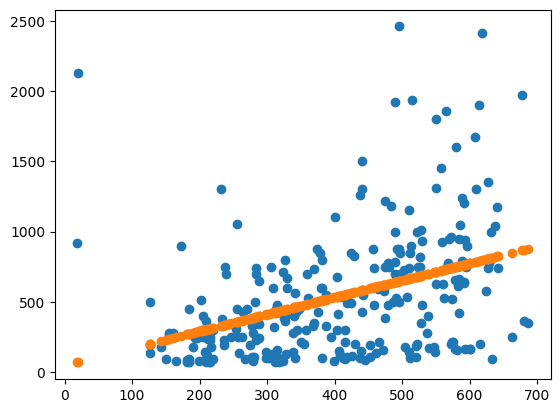

In [205]:
df['predicciones1'] = predicciones1
plt.scatter(df.AtBat, df.Salary)
plt.scatter(df.AtBat, df.predicciones1)

In [206]:
np.mean((df.predicciones1 - df.Salary)**2)

171139.3296801165

In [207]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.AtBat,
                   y_pred = df.predicciones1)

18442.7587587618

In [208]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.AtBat,
   y_pred = df.predicciones1)

0.14683635330929923

interpretaciones:

# bivariado Hits

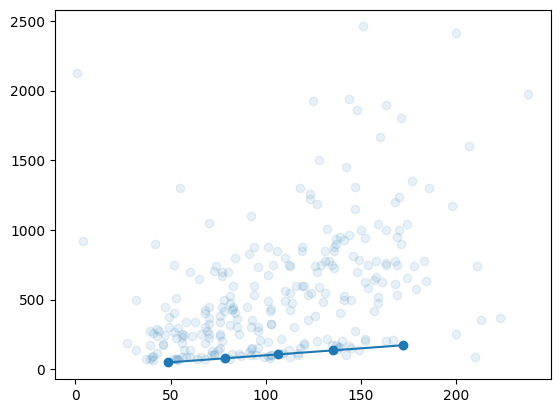

In [209]:
plt.scatter(df.Hits, df.Salary, alpha=0.1)
df['Hits_bin']= pd.qcut(df['Hits'], q=5, labels=False) + 1
grouped_Hits = df.groupby('Hits_bin').mean(numeric_only=True)
plt.plot(grouped_Hits.Hits.values, grouped_Hits.Hits.values, marker="o")

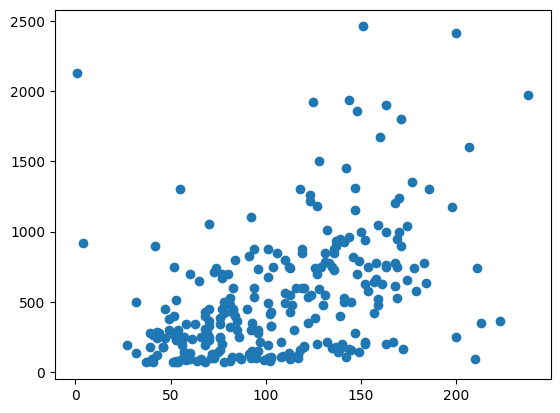

In [210]:
# Elimina los máximos y grafica
df = df[df.Hits != df.Salary.max()]
plt.scatter(df.Hits, df.Salary)

In [211]:
model2 = linear_model.LinearRegression()
X = df[['Hits']]
y = df[['Salary']]

# Fit the model to the data
model2.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model2.intercept_)
print(model2.coef_)

[63.04881891]
[[4.38543911]]


Ecuación:
$$Salary = 63.04+4.38 * Hits$$

In [212]:
# Aplicando el modelo1
63.04881891 + 4.38543911 * X

,Hits
1,418.269387
2,633.155903
3,681.395733
4,444.582021
5,804.188029
...,...
317,619.999586
318,659.468538
319,615.614147
320,694.552051


In [213]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones2 = model2.predict(X)
predicciones2

array([[ 418.26938655],
       [ 633.15590278],
       [ 681.39573296],
       [ 444.58202119],
       [ 804.18802794],
       [ 225.31006585],
       [ 383.1858737 ],
       [ 418.26938655],
       [ 466.50921672],
       [ 760.33363688],
       [ 295.47709156],
       [ 558.60343797],
       [ 326.17516531],
       [ 251.62270049],
       [ 755.94819777],
       [ 264.77901781],
       [ 203.38287032],
       [ 466.50921672],
       [ 541.06168154],
       [ 571.75975529],
       [ 799.80258884],
       [ 777.8753933 ],
       [ 383.1858737 ],
       [ 628.77046367],
       [ 729.63556313],
       [ 663.85397653],
       [ 536.67624243],
       [ 799.80258884],
       [ 277.93533514],
       [ 527.90536422],
       [ 326.17516531],
       [ 242.85182228],
       [ 264.77901781],
       [ 361.25867816],
       [ 641.92678099],
       [ 313.01884799],
       [ 703.32292849],
       [ 505.97816869],
       [ 295.47709156],
       [ 799.80258884],
       [ 505.97816869],
       [ 510.363

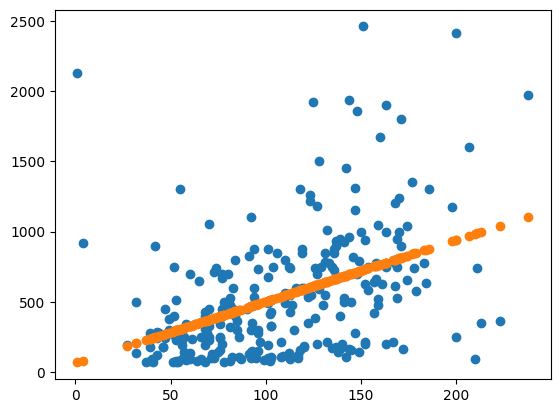

In [214]:
df['predicciones2'] = predicciones2
plt.scatter(df.Hits, df.Salary)
plt.scatter(df.Hits, df.predicciones2)

In [215]:
np.mean((df.predicciones2 - df.Salary)**2)

163720.99350664712

In [216]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.Hits,
                   y_pred = df.predicciones2)

206516.66982196504

In [217]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.Hits,
   y_pred = df.predicciones2)

-100.80494346484252

interpretaciones:


# Bivariado Hmrun


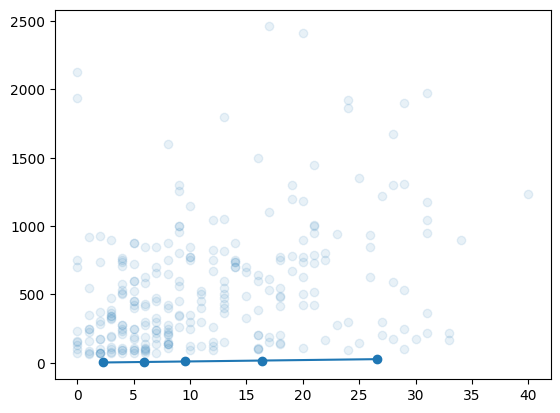

In [218]:
plt.scatter(df.HmRun, df.Salary, alpha=0.1)
df['HmRun_bin']= pd.qcut(df['HmRun'], q=5, labels=False) + 1
grouped_HmRun = df.groupby('HmRun_bin').mean(numeric_only=True)
plt.plot(grouped_HmRun.HmRun.values, grouped_HmRun.HmRun.values, marker="o")

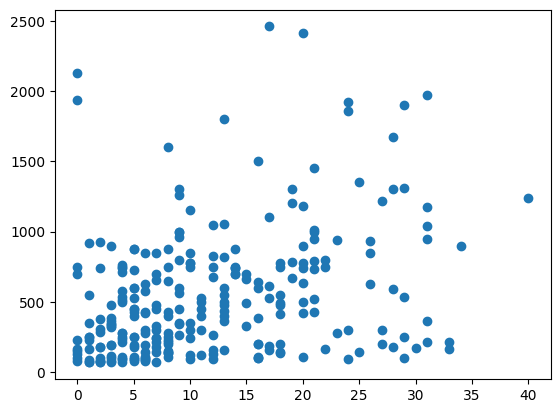

In [219]:
# Elimina los máximos y grafica
df = df[df.HmRun != df.Salary.max()]
plt.scatter(df.HmRun, df.Salary)

In [220]:
model3 = linear_model.LinearRegression()
X = df[['HmRun']]
y = df[['Salary']]

# Fit the model to the data
model3.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model3.intercept_)
print(model3.coef_)

[330.59352602]
[[17.67094557]]


Ecuación:

$$Salary = 330.59 + 17.67 * HmRuns$$

In [221]:
# Aplicando el modelo1
330.5935 + 17.6709 * X

,HmRun
1,454.2898
2,648.6697
3,684.0115
4,507.3025
5,401.2771
...,...
317,454.2898
318,418.9480
319,383.6062
320,489.6316


In [222]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones3 = model3.predict(X)
predicciones3

array([[ 454.290145  ],
       [ 648.67054625],
       [ 684.01243738],
       [ 507.3029817 ],
       [ 401.2773083 ],
       [ 348.26447159],
       [ 330.59352602],
       [ 436.61919943],
       [ 630.99960068],
       [ 701.68338295],
       [ 401.2773083 ],
       [ 560.31581841],
       [ 330.59352602],
       [ 454.290145  ],
       [ 684.01243738],
       [ 365.93541716],
       [ 471.96109057],
       [ 613.32865511],
       [ 383.60636273],
       [ 613.32865511],
       [ 648.67054625],
       [ 401.2773083 ],
       [ 401.2773083 ],
       [ 507.3029817 ],
       [ 436.61919943],
       [ 684.01243738],
       [ 436.61919943],
       [ 630.99960068],
       [ 436.61919943],
       [ 507.3029817 ],
       [ 418.94825386],
       [ 348.26447159],
       [ 454.290145  ],
       [ 365.93541716],
       [ 454.290145  ],
       [ 471.96109057],
       [ 560.31581841],
       [ 577.98676398],
       [ 365.93541716],
       [ 666.34149182],
       [ 542.64487284],
       [ 648.670

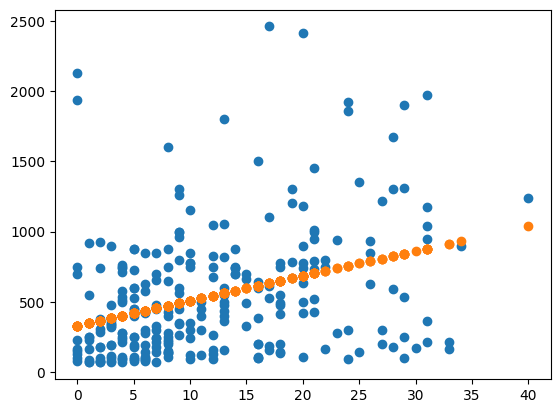

In [223]:
df['predicciones3'] = predicciones3
plt.scatter(df.HmRun, df.Salary)
plt.scatter(df.HmRun, df.predicciones3)

In [224]:
np.mean((df.predicciones3 - df.Salary)**2)

178878.8799770475

In [225]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.HmRun,
                   y_pred = df.predicciones3)

296128.72563293343

In [226]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.HmRun,
   y_pred = df.predicciones3)

-3875.2663385125006

interpretaciones:

bivariado Runs

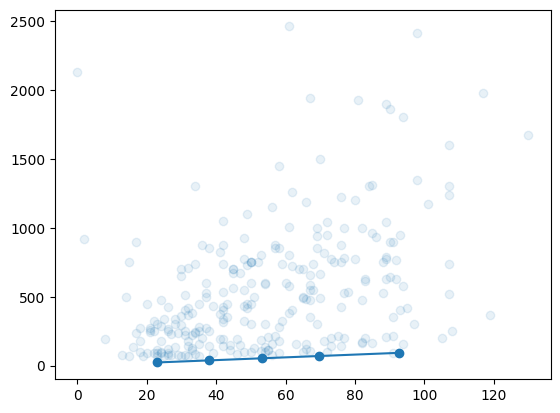

In [227]:
plt.scatter(df.Runs, df.Salary, alpha=0.1)
df['Runs_bin']= pd.qcut(df['Runs'], q=5, labels=False) + 1
grouped_Runs = df.groupby('Runs_bin').mean(numeric_only=True)
plt.plot(grouped_Runs.Runs.values, grouped_Runs.Runs.values, marker="o")

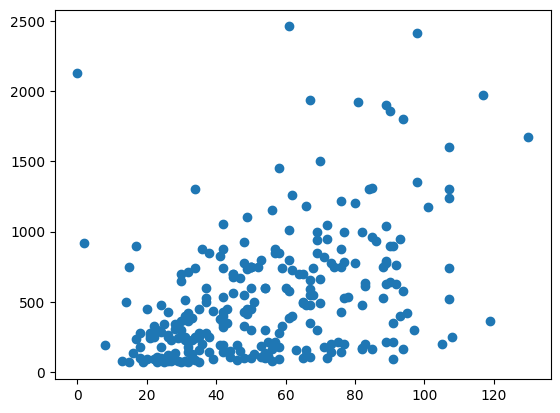

In [228]:
# Elimina los máximos y grafica
df = df[df.Runs != df.Salary.max()]
plt.scatter(df.Runs, df.Salary)

In [229]:
model4 = linear_model.LinearRegression()
X = df[['Runs']]
y = df[['Salary']]

# Fit the model to the data
model4.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model4.intercept_)
print(model4.coef_)

[129.92919863]
[[7.41610833]]


Ecuación:
$$Salary = 129.9291 + 7.4161 * Runs$$

In [230]:
# Aplicando el modelo1
129.9291 + 7.4161 * X

,Runs
1,307.9155
2,619.3917
3,611.9756
4,419.1570
5,678.7205
...,...
317,611.9756
318,693.5527
319,582.3112
320,760.2976


In [231]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones4 = model4.predict(X)
predicciones4

array([[ 307.91579859],
       [ 619.39234852],
       [ 611.97624019],
       [ 419.15742357],
       [ 678.72121518],
       [ 300.49969026],
       [ 307.91579859],
       [ 322.74801526],
       [ 493.31850689],
       [ 923.45279012],
       [ 359.82855691],
       [ 485.90239855],
       [ 352.41244858],
       [ 344.99634025],
       [ 789.96284015],
       [ 307.91579859],
       [ 248.58693194],
       [ 663.88899851],
       [ 537.81515688],
       [ 574.89569853],
       [ 671.30510685],
       [ 812.21116515],
       [ 367.24466525],
       [ 500.73461522],
       [ 812.21116515],
       [ 797.37894848],
       [ 537.81515688],
       [ 745.46619016],
       [ 300.49969026],
       [ 411.74131524],
       [ 307.91579859],
       [ 241.17082361],
       [ 367.24466525],
       [ 337.58023192],
       [ 552.64737354],
       [ 382.07688191],
       [ 656.47289018],
       [ 441.40574856],
       [ 352.41244858],
       [ 723.21786517],
       [ 463.65407356],
       [ 493.318

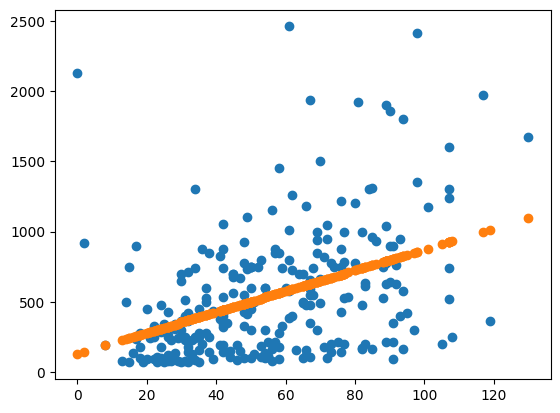

In [232]:
df['predicciones4'] = predicciones4
plt.scatter(df.Runs, df.Salary)
plt.scatter(df.Runs, df.predicciones4)

In [233]:
np.mean((df.predicciones4 - df.Salary)**2)

166996.0269193155

In [234]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.Runs,
                   y_pred = df.predicciones4)

258284.84337507602

In [235]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.Runs,
   y_pred = df.predicciones4)

-396.48236381795664

interpretaciones:

bivariado RBI

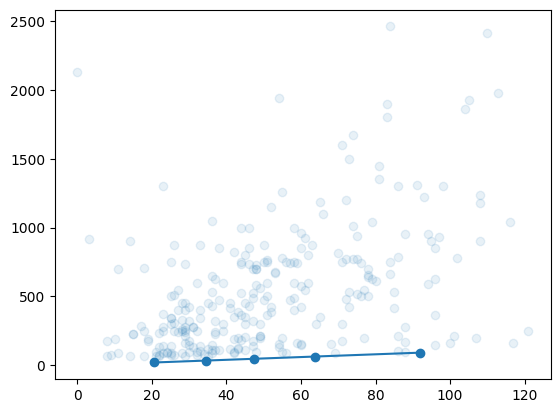

In [236]:
plt.scatter(df.RBI, df.Salary, alpha=0.1)
df['RBI_bin']= pd.qcut(df['RBI'], q=5, labels=False) + 1
grouped_RBI = df.groupby('RBI_bin').mean(numeric_only=True)
plt.plot(grouped_RBI.RBI.values, grouped_RBI.RBI.values, marker="o")

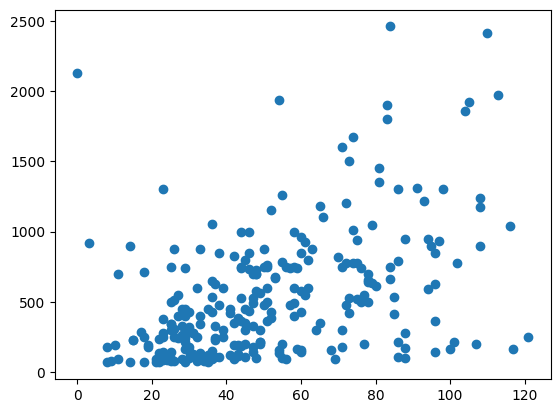

In [237]:
# Elimina los máximos y grafica
df = df[df.RBI != df.Salary.max()]
plt.scatter(df.RBI, df.Salary)

In [238]:
model5 = linear_model.LinearRegression()
X = df[['RBI']]
y = df[['Salary']]

# Fit the model to the data
model5.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model5.intercept_)
print(model5.coef_)

[132.59245505]
[[7.83374133]]


Ecuación:
$$132.5924 + 7.8337 * RBI$$

In [239]:
# Aplicando el modelo1
132.5924 + 7.8337 * X

,RBI
1,430.2730
2,696.6188
3,743.6210
4,461.6078
5,532.1111
...,...
317,508.6100
318,524.2774
319,469.4415
320,602.6144


In [240]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones5 = model5.predict(X)
predicciones5

array([[ 430.27462551],
       [ 696.62183066],
       [ 743.62427863],
       [ 461.60959082],
       [ 532.11326278],
       [ 195.26238567],
       [ 320.60224692],
       [ 383.27217754],
       [ 649.6193827 ],
       [ 720.12305465],
       [ 336.26972958],
       [ 610.45067606],
       [ 218.76360966],
       [ 344.1034709 ],
       [ 720.12305465],
       [ 195.26238567],
       [ 304.93476426],
       [ 508.61203879],
       [ 469.44333215],
       [ 618.28441738],
       [ 931.6340705 ],
       [ 532.11326278],
       [ 273.59979895],
       [ 571.28196942],
       [ 422.44088418],
       [ 876.79788121],
       [ 414.60714286],
       [ 759.29176129],
       [ 328.43598825],
       [ 602.61693473],
       [ 328.43598825],
       [ 297.10102294],
       [ 281.43354028],
       [ 336.26972958],
       [ 516.44578012],
       [ 383.27217754],
       [ 680.95434801],
       [ 626.11815871],
       [ 359.77095356],
       [ 696.62183066],
       [ 547.78074543],
       [ 798.460

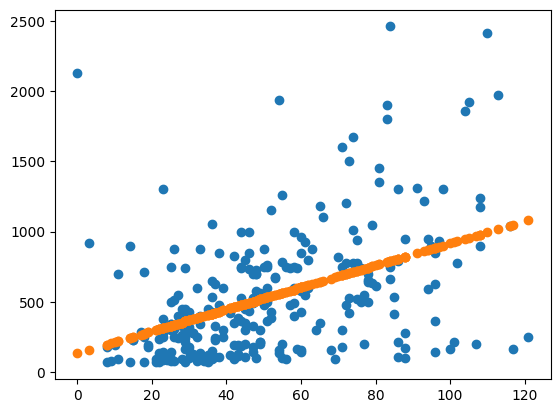

In [241]:
df['predicciones5'] = predicciones5
plt.scatter(df.RBI, df.Salary)
plt.scatter(df.RBI, df.predicciones5)

In [242]:
np.mean((df.predicciones5 - df.Salary)**2)

161779.5800888706

In [243]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.RBI,
                   y_pred = df.predicciones5)

265847.4139165476

In [244]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.RBI,
   y_pred = df.predicciones5)

-397.3522373918384

interpretaciones:

bivariado Walks

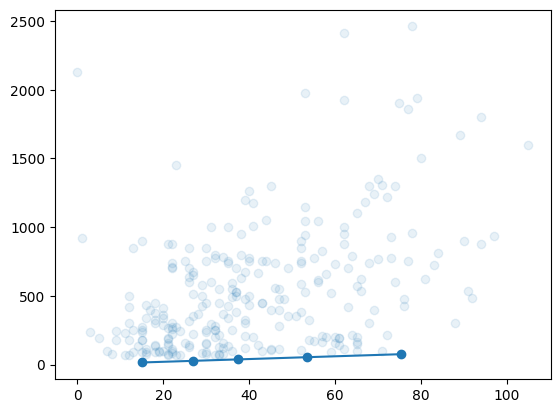

In [245]:
plt.scatter(df.Walks, df.Salary, alpha=0.1)
df['Walks_bin']= pd.qcut(df['Walks'], q=5, labels=False) + 1
grouped_Walks = df.groupby('Walks_bin').mean(numeric_only=True)
plt.plot(grouped_Walks.Walks.values, grouped_Walks.Walks.values, marker="o")

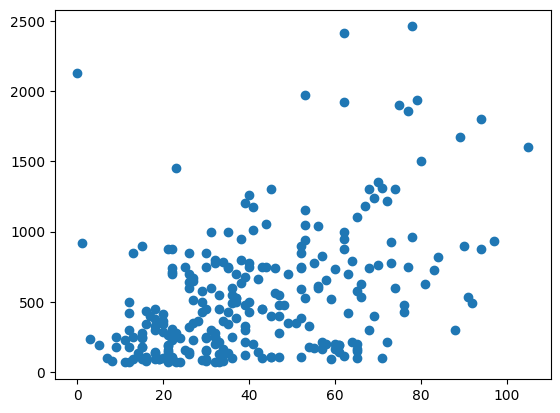

In [246]:
# Elimina los máximos y grafica
df = df[df.Walks != df.Salary.max()]
plt.scatter(df.Walks, df.Salary)

In [247]:
model6 = linear_model.LinearRegression()
X = df[['Walks']]
y = df[['Salary']]

# Fit the model to the data
model6.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model6.intercept_)
print(model6.coef_)

[156.86110852]
[[9.21983126]]


Ecuación:
$$156.8611 + 9.2198 * Walks$$

In [248]:
# Aplicando el modelo1
156.8611 + 9.2198 * X

,Walks
1,516.4333
2,857.5659
3,497.9937
4,433.4551
5,479.5541
...,...
317,497.9937
318,1023.5223
319,636.2907
320,876.0055


In [249]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones6 = model6.predict(X)
predicciones6

array([[ 516.43452782],
       [ 857.5682846 ],
       [ 497.99486529],
       [ 433.45604644],
       [ 479.55520277],
       [ 350.47756507],
       [ 221.39992737],
       [ 230.61975863],
       [ 756.15014069],
       [ 700.83115311],
       [ 405.79655265],
       [ 590.19317794],
       [ 359.69739633],
       [ 433.45604644],
       [ 829.9087908 ],
       [ 295.15857748],
       [ 285.93874622],
       [ 756.15014069],
       [ 728.4906469 ],
       [ 839.12862207],
       [ 525.65435909],
       [ 802.24929701],
       [ 359.69739633],
       [ 525.65435909],
       [ 903.66744092],
       [ 986.64592229],
       [ 359.69739633],
       [ 673.17165931],
       [ 267.49908369],
       [ 433.45604644],
       [ 295.15857748],
       [ 461.11554024],
       [ 239.8395899 ],
       [ 359.69739633],
       [ 461.11554024],
       [ 239.8395899 ],
       [ 931.32693471],
       [ 359.69739633],
       [ 368.91722759],
       [ 516.43452782],
       [ 516.43452782],
       [ 341.257

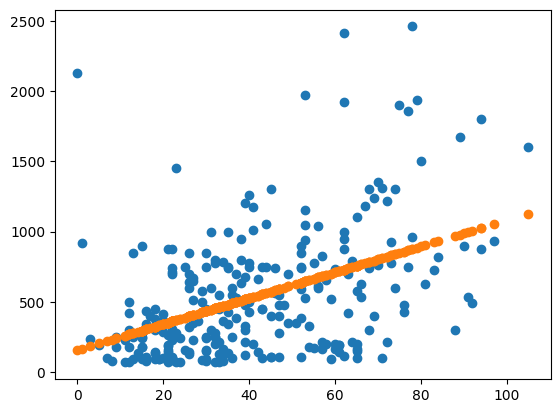

In [250]:
df['predicciones6'] = predicciones6
plt.scatter(df.Walks, df.Salary)
plt.scatter(df.Walks, df.predicciones6)

In [251]:
np.mean((df.predicciones6 - df.Salary)**2)

162791.93959289277

In [252]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.Walks,
                   y_pred = df.predicciones6)

276586.5027547307

In [253]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.Walks,
   y_pred = df.predicciones6)

-587.6315527585062

interpretaciones:

Bivariado Years

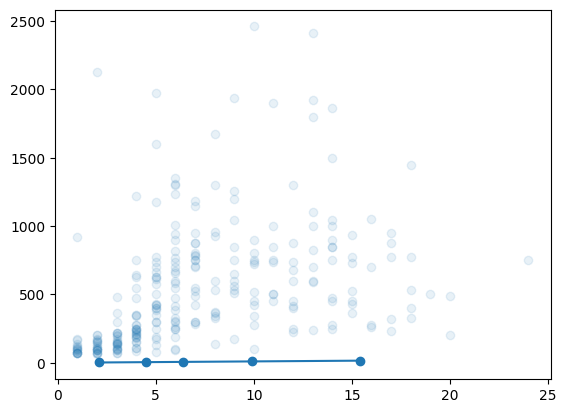

In [254]:
plt.scatter(df.Years, df.Salary, alpha=0.1)
df['Years_bin']= pd.qcut(df['Years'], q=5, labels=False) + 1
grouped_Years = df.groupby('Years_bin').mean(numeric_only=True)
plt.plot(grouped_Years.Years.values, grouped_Years.Years.values, marker="o")

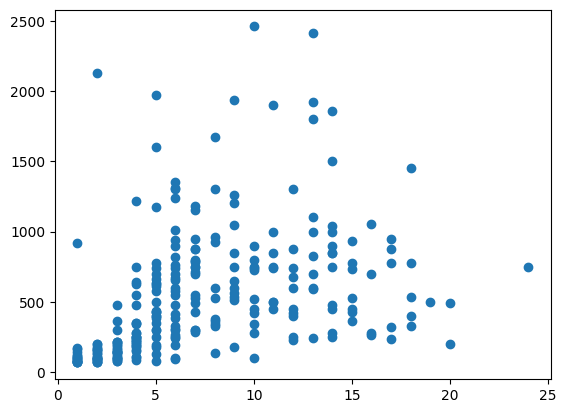

In [255]:
# Elimina los máximos y grafica
df = df[df.Years != df.Salary.max()]
plt.scatter(df.Years, df.Salary)

In [256]:
model7 = linear_model.LinearRegression()
X = df[['Years']]
y = df[['Salary']]

# Fit the model to the data
model7.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model7.intercept_)
print(model7.coef_)

[260.234087]
[[37.70511811]]


Ecuación:
$$260.23 + 37.70 * Years$$

In [257]:
# Aplicando el modelo1
260.23 + 37.70 * X

,Years
1,788.03
2,373.33
3,674.93
4,335.63
5,674.93
...,...
317,448.73
318,712.63
319,486.43
320,561.83


In [258]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones7 = model7.predict(X)
predicciones7

array([[ 788.10574049],
       [ 373.34944132],
       [ 674.99038617],
       [ 335.64432321],
       [ 674.99038617],
       [ 335.64432321],
       [ 373.34944132],
       [ 335.64432321],
       [ 750.40062239],
       [ 637.28526807],
       [ 599.58014996],
       [ 411.05455943],
       [ 486.46479564],
       [ 750.40062239],
       [ 825.8108586 ],
       [ 448.75967753],
       [ 561.87503185],
       [ 297.93920511],
       [ 297.93920511],
       [ 486.46479564],
       [ 938.92621292],
       [ 486.46479564],
       [ 524.16991375],
       [ 637.28526807],
       [ 448.75967753],
       [ 788.10574049],
       [ 373.34944132],
       [ 448.75967753],
       [ 524.16991375],
       [ 788.10574049],
       [ 335.64432321],
       [ 335.64432321],
       [ 411.05455943],
       [ 486.46479564],
       [ 373.34944132],
       [ 448.75967753],
       [ 486.46479564],
       [ 901.22109481],
       [ 335.64432321],
       [ 599.58014996],
       [ 712.69550428],
       [ 486.464

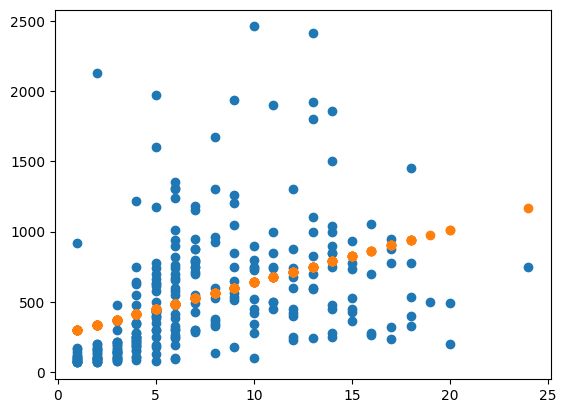

In [259]:
df['predicciones7'] = predicciones7
plt.scatter(df.Years, df.Salary)
plt.scatter(df.Years, df.predicciones7)

In [260]:
np.mean((df.predicciones7 - df.Salary)**2)

170190.14236365163

In [261]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.Years,
                   y_pred = df.predicciones7)

310273.63514747005

In [262]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.Years,
   y_pred = df.predicciones7)

-13553.167915802176

interpretaciones:

Bivariado CAtBat

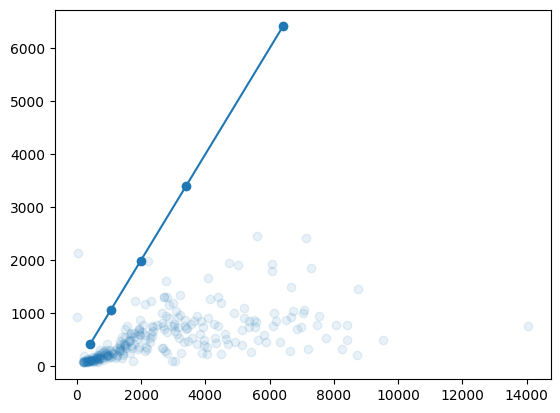

In [263]:
plt.scatter(df.CAtBat, df.Salary, alpha=0.1)
df['CAtBat_bin']= pd.qcut(df['CAtBat'], q=5, labels=False) + 1
grouped_CAtBat = df.groupby('CAtBat_bin').mean(numeric_only=True)
plt.plot(grouped_CAtBat.CAtBat.values, grouped_CAtBat.CAtBat.values, marker="o")

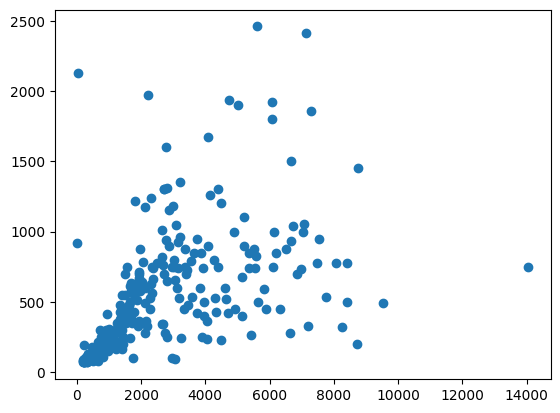

In [264]:
# Elimina los máximos y grafica
df = df[df.CAtBat != df.Salary.max()]
plt.scatter(df.CAtBat, df.Salary)

In [265]:
model8 = linear_model.LinearRegression()
X = df[['CAtBat']]
y = df[['Salary']]

# Fit the model to the data
model8.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model8.intercept_)
print(model8.coef_)

[260.07033447]
[[0.10380094]]


Ecuación:
$$Salary = 260.07 + 0.103 * CAtBat$$

In [266]:
# Aplicando el modelo1
260.07 + 0.1038 * X

,CAtBat
1,618.0762
2,428.6412
3,844.2564
4,301.1748
5,717.6204
...,...
317,540.6414
318,832.1118
319,436.5300
320,592.0224


In [267]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones8 = model8.predict(X)
predicciones8

array([[ 618.07979053],
       [ 428.64306762],
       [ 844.26204763],
       [ 301.17550831],
       [ 717.62489588],
       [ 282.2837365 ],
       [ 312.90501499],
       [ 295.46645639],
       [ 800.45804924],
       [ 740.77250641],
       [ 454.80090552],
       [ 417.01736188],
       [ 461.54796689],
       [ 595.45118472],
       [1097.53635114],
       [ 309.79098667],
       [ 335.5336208 ],
       [ 302.94012436],
       [ 304.28953664],
       [ 459.78335084],
       [1134.48948722],
       [ 539.81387871],
       [ 460.50995745],
       [ 502.03033507],
       [ 499.64291336],
       [ 799.93904452],
       [ 321.41669241],
       [ 430.92668839],
       [ 395.94577024],
       [ 904.36279424],
       [ 296.40066489],
       [ 284.15215349],
       [ 332.10818964],
       [ 363.76747758],
       [ 356.81281433],
       [ 338.54384818],
       [ 534.93523434],
       [ 936.95629068],
       [ 283.52934782],
       [ 724.89096197],
       [ 794.64519637],
       [ 358.681

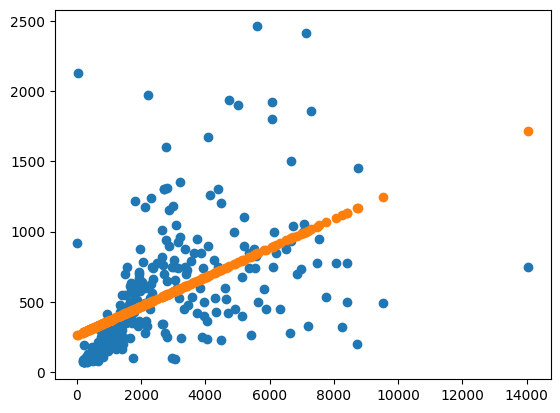

In [268]:
df['predicciones8'] = predicciones8
plt.scatter(df.CAtBat, df.Salary)
plt.scatter(df.CAtBat, df.predicciones8)

In [269]:
np.mean((df.predicciones8 - df.Salary)**2)

146613.70043652388

In [270]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.CAtBat,
                   y_pred = df.predicciones8)

8684652.921272317

In [271]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.CAtBat,
   y_pred = df.predicciones8)

-0.6673739421551383

interpretaciones:

  Bivariado CHits

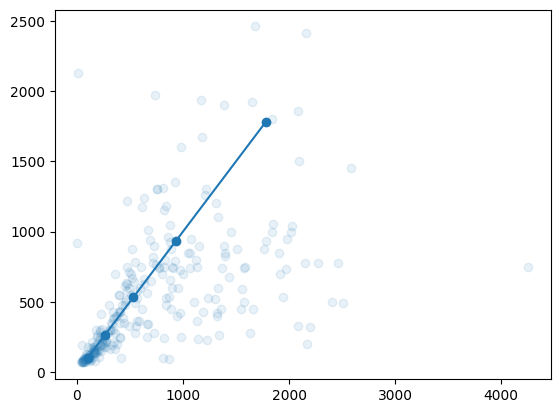

In [272]:
plt.scatter(df.CHits, df.Salary, alpha=0.1)
df['CHits_bin']= pd.qcut(df['CHits'], q=5, labels=False) + 1
grouped_CHits = df.groupby('CHits_bin').mean(numeric_only=True)
plt.plot(grouped_CHits.CHits.values, grouped_CHits.CHits.values, marker="o")

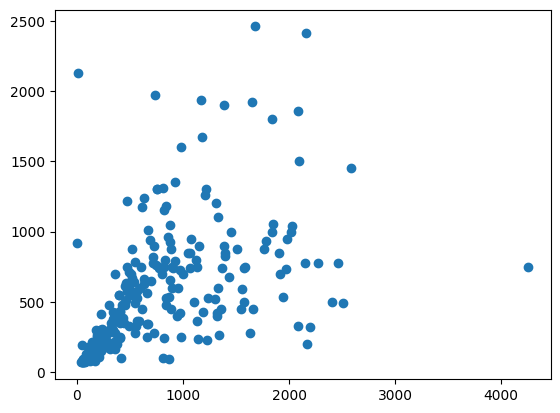

In [273]:
# Elimina los máximos y grafica
df = df[df.CHits != df.Salary.max()]
plt.scatter(df.CHits, df.Salary)

In [274]:
model9 = linear_model.LinearRegression()
X = df[['CHits']]
y = df[['Salary']]

# Fit the model to the data
model9.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model9.intercept_)
print(model9.coef_)

[260.03835275]
[[0.38201711]]


Ecuación:
$$Salary = 260.03 + 0.38 * CHits$$

In [275]:
# Aplicando el modelo1
260.0383 + 0.3820 * X

,CHits
1,579.0083
2,434.6123
3,861.6883
4,298.6203
5,692.8443
...,...
317,567.9303
318,837.2403
319,425.4443
320,587.4123


In [276]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones9 = model9.predict(X)
predicciones9

array([[ 579.02264153],
       [ 434.62017308],
       [ 861.71530464],
       [ 298.6220811 ],
       [ 692.863741  ],
       [ 276.08307147],
       [ 301.29620088],
       [ 292.89182441],
       [ 768.88514635],
       [ 756.66059875],
       [ 438.4403442 ],
       [ 409.78906078],
       [ 454.86708003],
       [ 575.20247041],
       [1128.36324903],
       [ 299.00409821],
       [ 328.80143297],
       [ 295.18392708],
       [ 301.67821799],
       [ 446.84472067],
       [1201.32851748],
       [ 545.40513565],
       [ 447.6087549 ],
       [ 490.77668859],
       [ 501.85518484],
       [ 787.98600196],
       [ 316.95890249],
       [ 432.71008752],
       [ 377.69962334],
       [ 988.16296881],
       [ 289.83568751],
       [ 279.13920837],
       [ 321.16109072],
       [ 350.19439126],
       [ 364.32902441],
       [ 333.38563832],
       [ 533.18058805],
       [ 935.0625902 ],
       [ 282.57736238],
       [ 759.33471854],
       [ 805.94080624],
       [ 348.284

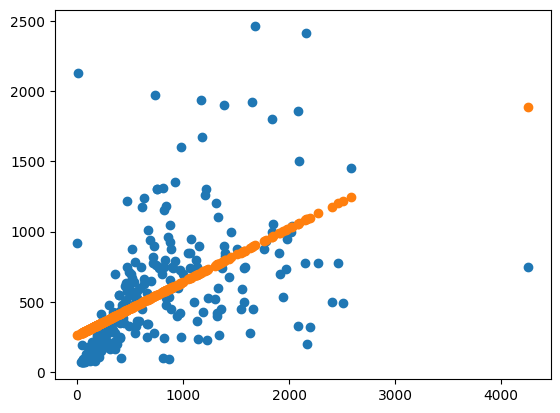

In [277]:
df['predicciones9'] = predicciones9
plt.scatter(df.CHits, df.Salary)
plt.scatter(df.CHits, df.predicciones9)

In [278]:
np.mean((df.predicciones9 - df.Salary)**2)

141650.08840170503

In [279]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.CHits,
                   y_pred = df.predicciones9)

194544.1906227247

In [280]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.CHits,
   y_pred = df.predicciones9)

0.5352117420552667

interpretaciones:

Bivariado CHmRun

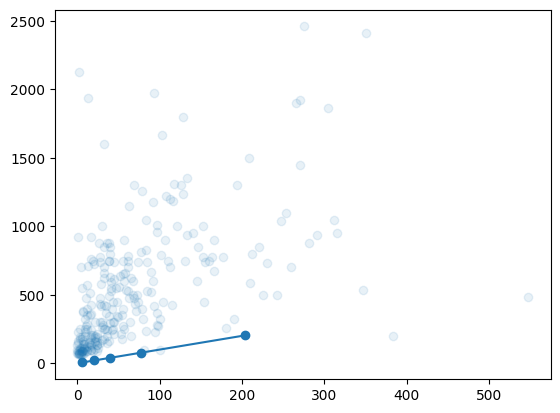

In [281]:
plt.scatter(df.CHmRun, df.Salary, alpha=0.1)
df['CHmRun_bin']= pd.qcut(df['CHmRun'], q=5, labels=False) + 1
grouped_CHmRun = df.groupby('CHmRun_bin').mean(numeric_only=True)
plt.plot(grouped_CHmRun.CHmRun.values, grouped_CHmRun.CHmRun.values, marker="o")

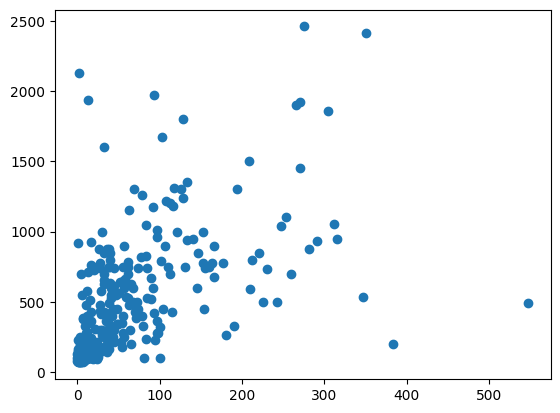

In [282]:
# Elimina los máximos y grafica
df = df[df.CHmRun != df.Salary.max()]
plt.scatter(df.CHmRun, df.Salary)

In [283]:
model10 = linear_model.LinearRegression()
X = df[['CHmRun']]
y = df[['Salary']]

# Fit the model to the data
model10.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model10.intercept_)
print(model10.coef_)

[336.45117964]
[[2.88093612]]


Ecuación:
$$Salary = 336.45 + 2.88 * CHmRun$$

In [284]:
# Aplicando el modelo1
336.45 + 2.88 * X

,CHmRun
1,535.17
2,517.89
3,984.45
4,371.01
5,391.17
...,...
317,428.61
318,448.77
319,356.61
320,615.81


In [285]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones10 = model10.predict(X)
predicciones10

array([[ 535.23577196],
       [ 517.95015523],
       [ 984.66180676],
       [ 371.02241309],
       [ 391.18896593],
       [ 339.33211576],
       [ 336.45117964],
       [ 353.73679636],
       [1065.32801813],
       [ 595.73543049],
       [ 379.66522145],
       [ 454.56956058],
       [ 347.97492412],
       [ 440.16487998],
       [ 846.37687297],
       [ 350.85586024],
       [ 405.59364653],
       [ 382.54615757],
       [ 345.093988  ],
       [ 529.47389971],
       [ 808.92470341],
       [ 385.42709369],
       [ 373.90334921],
       [ 512.18828299],
       [ 428.6411355 ],
       [ 814.68657565],
       [ 359.4986686 ],
       [ 463.21236894],
       [ 414.23645489],
       [ 757.06785324],
       [ 350.85586024],
       [ 347.97492412],
       [ 428.6411355 ],
       [ 396.95083817],
       [ 405.59364653],
       [ 428.6411355 ],
       [ 558.28326092],
       [1145.99422951],
       [ 342.21305188],
       [ 661.99696126],
       [ 814.68657565],
       [ 419.998

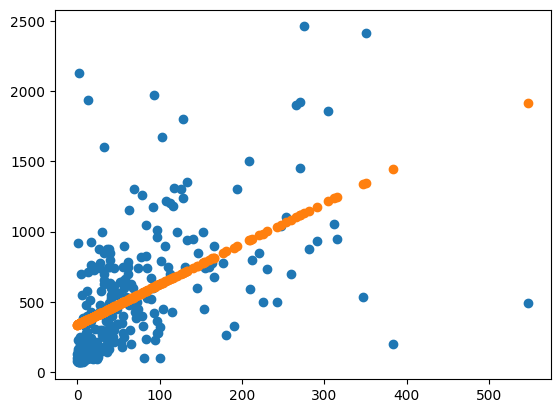

In [286]:
df['predicciones10'] = predicciones10
plt.scatter(df.CHmRun, df.Salary)
plt.scatter(df.CHmRun, df.predicciones10)

In [287]:
np.mean((df.predicciones10 - df.Salary)**2)

146870.4171021864

In [288]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.CHmRun,
                   y_pred = df.predicciones10)

241609.0069944866

In [289]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.CHmRun,
   y_pred = df.predicciones10)

-34.89628452755105

interpretaciones:

Bivariado CRuns

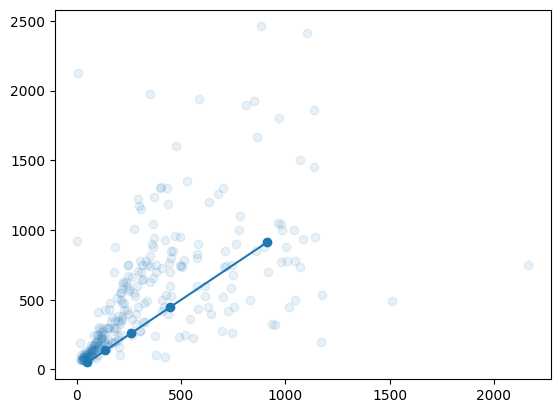

In [290]:
plt.scatter(df.CRuns, df.Salary, alpha=0.1)
df['CRuns_bin']= pd.qcut(df['CRuns'], q=5, labels=False) + 1
grouped_CRuns = df.groupby('CRuns_bin').mean(numeric_only=True)
plt.plot(grouped_CRuns.CRuns.values, grouped_CRuns.CRuns.values, marker="o")

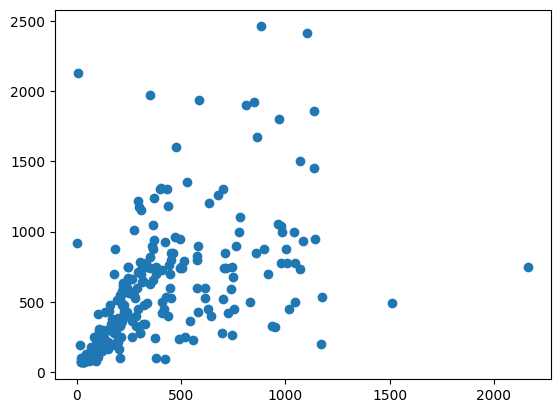

In [291]:
# Elimina los máximos y grafica
df = df[df.CRuns != df.Salary.max()]
plt.scatter(df.CRuns, df.Salary)

In [292]:
model11 = linear_model.LinearRegression()
X = df[['CRuns']]
y = df[['Salary']]

# Fit the model to the data
model11.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model11.intercept_)
print(model11.coef_)

[259.08227574]
[[0.7664116]]


Ecuación:
$$259.08 + 0.76 * CRuns$$

In [293]:
# Aplicando el modelo1
259.08 + 0.76 * X

,CRuns
1,503.04
2,429.32
3,888.36
4,295.56
5,639.84
...,...
317,547.12
318,940.80
319,424.00
320,616.28


In [294]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones11 = model11.predict(X)
predicciones11

array([[ 505.10039957],
       [ 430.7584743 ],
       [ 893.67108114],
       [ 295.87003257],
       [ 643.0544877 ],
       [ 282.07462376],
       [ 290.50515137],
       [ 283.60744696],
       [ 859.94897071],
       [ 797.10321945],
       [ 406.23330308],
       [ 416.19665389],
       [ 495.90346036],
       [ 547.25303761],
       [1059.9823985 ],
       [ 308.89902979],
       [ 310.43185299],
       [ 314.26391099],
       [ 301.23491378],
       [ 444.55388311],
       [1031.62516927],
       [ 597.83620326],
       [ 482.10805155],
       [ 447.61952952],
       [ 526.55992439],
       [ 843.85432709],
       [ 320.3952038 ],
       [ 426.9264163 ],
       [ 355.65013743],
       [ 917.42984076],
       [ 285.14027016],
       [ 274.41050775],
       [ 324.9936734 ],
       [ 341.85472862],
       [ 345.68678662],
       [ 348.75243302],
       [ 528.85915919],
       [1027.79311127],
       [ 283.60744696],
       [ 744.9872306 ],
       [ 831.59174148],
       [ 334.957

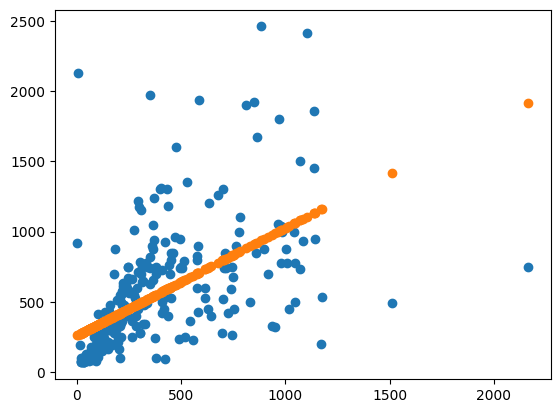

In [295]:
df['predicciones11'] = predicciones11
plt.scatter(df.CRuns, df.Salary)
plt.scatter(df.CRuns, df.predicciones11)

In [296]:
np.mean((df.predicciones11 - df.Salary)**2)

138547.3412803566

In [297]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.CRuns,
                   y_pred = df.predicciones11)

36484.412565365834

In [298]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.CRuns,
   y_pred = df.predicciones11)

0.6661242260809639

interpretaciones:

Bivariado CRBI

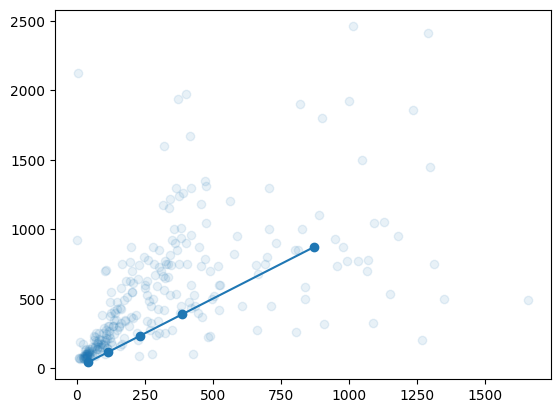

In [299]:
plt.scatter(df.CRBI, df.Salary, alpha=0.1)
df['CRBI_bin']= pd.qcut(df['CRBI'], q=5, labels=False) + 1
grouped_CRBI = df.groupby('CRBI_bin').mean(numeric_only=True)
plt.plot(grouped_CRBI.CRBI.values, grouped_CRBI.CRBI.values, marker="o")

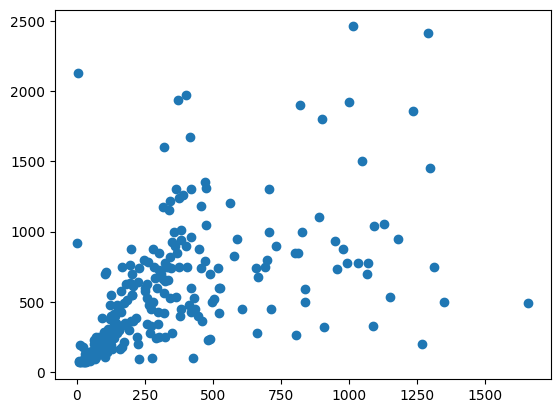

In [300]:
# Elimina los máximos y grafica
df = df[df.CRBI != df.Salary.max()]
plt.scatter(df.CRBI, df.Salary)

In [301]:
model12 = linear_model.LinearRegression()
X = df[['CRBI']]
y = df[['Salary']]

# Fit the model to the data
model12.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model12.intercept_)
print(model12.coef_)

[274.58038641]
[[0.79095357]]


Ecuación:
$$247.58 + 0.79 * CRBI$$

In [302]:
# Aplicando el modelo1
274.58 + 0.79 * X

,CRBI
1,601.64
2,484.72
3,936.60
4,310.92
5,540.02
...,...
317,520.27
318,630.87
319,348.05
320,606.38


In [303]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones12 = model12.predict(X)
predicciones12

array([[ 602.03516506],
       [ 484.97403646],
       [ 937.39947944],
       [ 310.9642507 ],
       [ 540.34078648],
       [ 281.69896855],
       [ 303.84566856],
       [ 301.47280784],
       [ 978.52906516],
       [ 673.22098651],
       [ 421.69775073],
       [ 435.93491502],
       [ 356.04860429],
       [ 503.95692218],
       [1059.99728304],
       [ 292.77231856],
       [ 339.43857928],
       [ 312.54615785],
       [ 308.59138999],
       [ 473.10973289],
       [1122.4826152 ],
       [ 431.18919359],
       [ 360.00337214],
       [ 533.22220433],
       [ 418.53393644],
       [ 855.14030799],
       [ 310.9642507 ],
       [ 439.09872931],
       [ 378.98625786],
       [ 909.71610443],
       [ 297.51803998],
       [ 297.51803998],
       [ 334.69285785],
       [ 367.12195429],
       [ 370.28576857],
       [ 359.21241857],
       [ 545.08650791],
       [1047.34202589],
       [ 299.8909007 ],
       [ 719.88724724],
       [ 801.35546511],
       [ 383.731

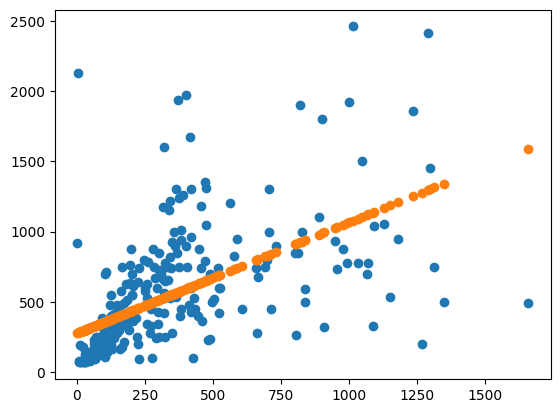

In [304]:
df['predicciones12'] = predicciones12
plt.scatter(df.CRBI, df.Salary)
plt.scatter(df.CRBI, df.predicciones12)

In [305]:
np.mean((df.predicciones12 - df.Salary)**2)

137565.32036137575

In [306]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.CRBI,
                   y_pred = df.predicciones12)

46785.616891190766

In [307]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.CRBI,
   y_pred = df.predicciones12)

0.5508683841804602

interpretaciones:

Bivariado CWalks

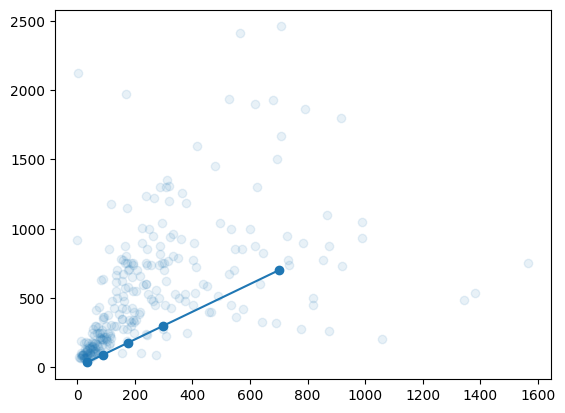

In [308]:
plt.scatter(df.CWalks, df.Salary, alpha=0.1)
df['CWalks_bin']= pd.qcut(df['CWalks'], q=5, labels=False) + 1
grouped_CWalks = df.groupby('CWalks_bin').mean(numeric_only=True)
plt.plot(grouped_CWalks.CWalks.values, grouped_CWalks.CWalks.values, marker="o")

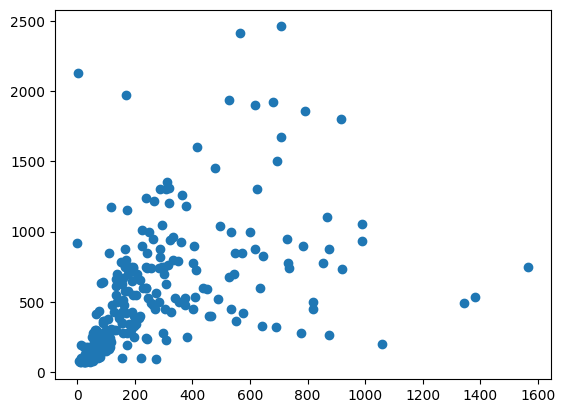

In [309]:
# Elimina los máximos y grafica
df = df[df.CWalks != df.Salary.max()]
plt.scatter(df.CWalks, df.Salary)

In [310]:
model13 = linear_model.LinearRegression()
X = df[['CWalks']]
y = df[['Salary']]

# Fit the model to the data
model13.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model13.intercept_)
print(model13.coef_)

[318.12932419]
[[0.83682242]]


Ecuación:
$$ 318.12 + 0.83 * CWalks$$

In [311]:
# Aplicando el modelo1
318.12 + 0.83 * X

,CWalks
1,629.37
2,536.41
3,611.94
4,345.51
5,479.14
...,...
317,432.66
318,1044.37
319,439.30
320,593.68


In [312]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones13 = model13.predict(X)
predicciones13

array([[ 631.93773218],
       [ 538.21362099],
       [ 614.36446133],
       [ 345.7444641 ],
       [ 480.47287392],
       [ 338.21306231],
       [ 328.17119325],
       [ 324.82390356],
       [1042.81754103],
       [ 726.49866578],
       [ 452.85773402],
       [ 488.00427572],
       [ 491.3515654 ],
       [ 517.29306046],
       [ 930.68333657],
       [ 350.76539862],
       [ 364.99137979],
       [ 372.52278158],
       [ 370.01231431],
       [ 518.9667053 ],
       [ 654.53193755],
       [ 583.40203174],
       [ 468.75736003],
       [ 457.04184613],
       [ 575.87062995],
       [ 974.19810248],
       [ 344.07081925],
       [ 431.93717349],
       [ 373.359604  ],
       [ 795.95492675],
       [ 333.19212778],
       [ 355.78633315],
       [ 344.90764168],
       [ 416.87436991],
       [ 385.0751179 ],
       [ 360.80726768],
       [ 559.97100395],
       [ 836.12240297],
       [ 340.72352957],
       [ 585.07567658],
       [ 758.29791779],
       [ 371.685

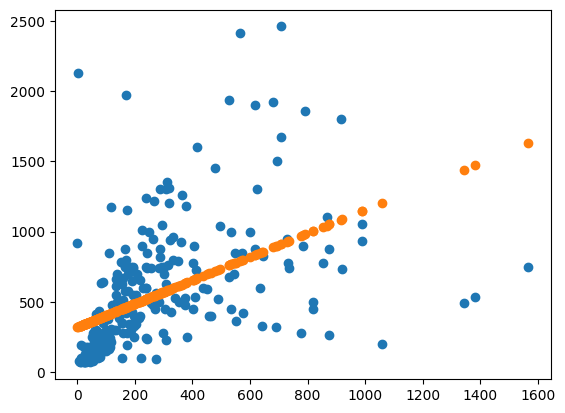

In [313]:
df['predicciones13'] = predicciones13
plt.scatter(df.CWalks, df.Salary)
plt.scatter(df.CWalks, df.predicciones13)

In [314]:
np.mean((df.predicciones13 - df.Salary)**2)

154093.12247029532

In [315]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.CWalks,
                   y_pred = df.predicciones13)

77837.79885071224

In [316]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.CWalks,
   y_pred = df.predicciones13)

-0.12060706783780795

interpretaciones:

Bivariado PutOuts

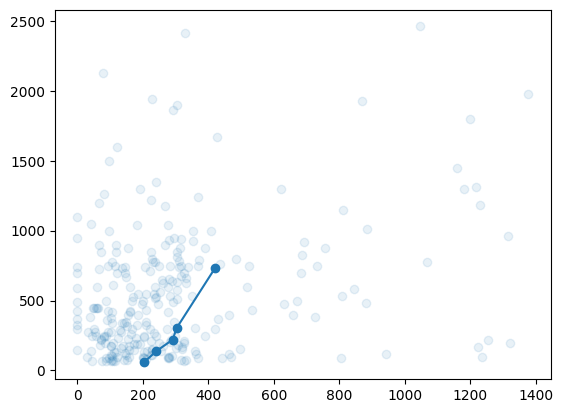

In [317]:
plt.scatter(df.PutOuts, df.Salary, alpha=0.1)
df['PutOuts_bin']= pd.qcut(df['PutOuts'], q=5, labels=False) + 1
grouped_PutOuts = df.groupby('PutOuts_bin').mean(numeric_only=True)
plt.plot(grouped_Runs.PutOuts.values, grouped_PutOuts.PutOuts.values, marker="o")

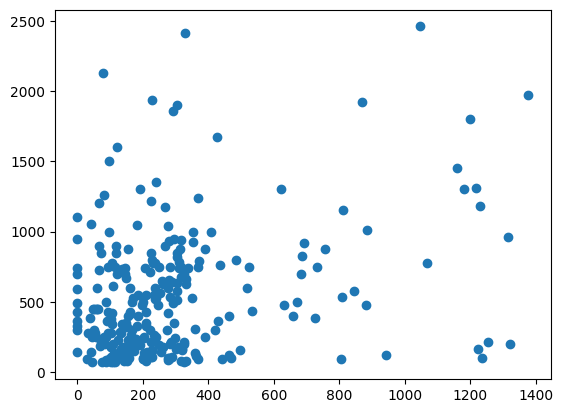

In [318]:
# Elimina los máximos y grafica
df = df[df.PutOuts != df.Salary.max()]
plt.scatter(df.PutOuts, df.Salary)

In [319]:
model14 = linear_model.LinearRegression()
X = df[['PutOuts']]
y = df[['Salary']]

# Fit the model to the data
model14.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model14.intercept_)
print(model14.coef_)

[395.15531574]
[[0.48422851]]


Ecuación:
$$ 395.15 + 0.48 * PutOuts$$

In [320]:
# Aplicando el modelo1
395.15 + 0.48 * X

,PutOuts
1,698.51
2,817.55
3,491.15
4,781.55
5,530.51
...,...
317,551.15
318,545.39
319,412.91
320,1025.87


In [321]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones14 = model14.predict(X)
predicciones14

array([[ 701.18773217],
       [ 821.27640191],
       [ 492.00101714],
       [ 784.95926388],
       [ 531.70775472],
       [ 431.95668227],
       [ 453.74696509],
       [ 464.39999224],
       [ 395.15531574],
       [ 510.40170041],
       [ 542.36078187],
       [ 497.32753072],
       [ 453.74696509],
       [ 433.8935963 ],
       [ 445.99930898],
       [ 444.54662345],
       [ 492.96947416],
       [ 530.7392977 ],
       [ 569.96180677],
       [ 645.98568237],
       [ 911.82713272],
       [ 605.31048778],
       [ 502.6540443 ],
       [ 749.61058287],
       [ 522.02318458],
       [ 524.44432711],
       [ 504.59095832],
       [ 447.936223  ],
       [ 598.04706018],
       [ 430.01976824],
       [ 609.18431584],
       [ 553.01380903],
       [ 543.81346739],
       [ 568.99334976],
       [ 430.50399675],
       [ 423.24056915],
       [ 541.87655336],
       [ 583.52020497],
       [ 447.936223  ],
       [ 427.59862571],
       [ 548.17152395],
       [ 473.116

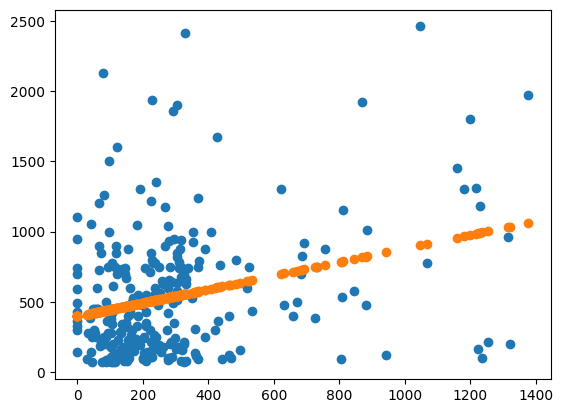

In [322]:
df['predicciones14'] = predicciones14
plt.scatter(df.PutOuts, df.Salary)
plt.scatter(df.PutOuts, df.predicciones14)

In [323]:
np.mean((df.predicciones14 - df.Salary)**2)

184429.70744143685

In [324]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.PutOuts,
                   y_pred = df.predicciones14)

80897.30311911451

In [325]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.PutOuts,
   y_pred = df.predicciones14)

-0.03627594141468138

interpretaciones:

Bivariado	Assists

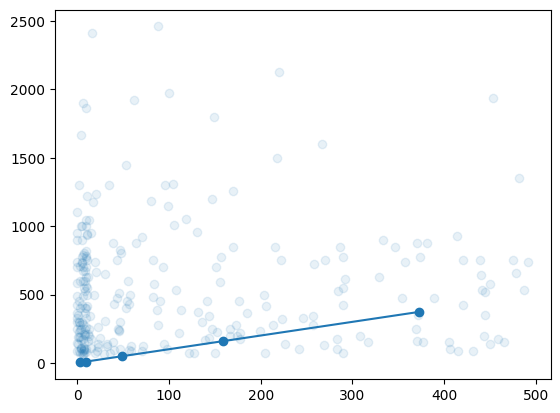

In [326]:
plt.scatter(df.Assists, df.Salary, alpha=0.1)
df['Assists_bin']= pd.qcut(df['Assists'], q=5, labels=False) + 1
grouped_Assists = df.groupby('Assists_bin').mean(numeric_only=True)
plt.plot(grouped_Assists.Assists.values, grouped_Assists.Assists.values, marker="o")

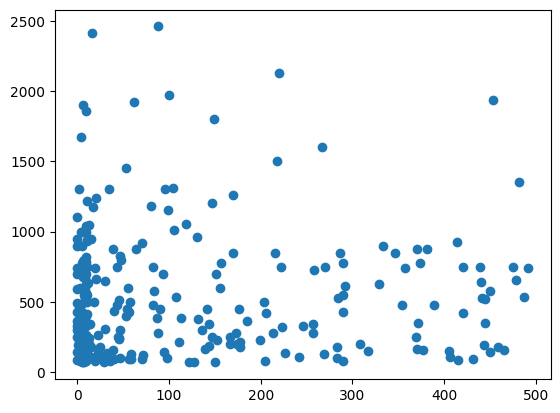

In [327]:
# Elimina los máximos y grafica
df = df[df.Assists != df.Salary.max()]
plt.scatter(df.Assists, df.Salary)

In [328]:
model15 = linear_model.LinearRegression()
X = df[['Assists']]
y = df[['Salary']]

# Fit the model to the data
model15.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model15.intercept_)
print(model15.coef_)

[526.53287767]
[[0.07909202]]


Ecuación:
$$ 526.5328 + 0.079 * Assists$$

In [329]:
# Aplicando el modelo1
526.5328 + 0.079 * X

,Assists
1,529.9298
2,533.0108
3,527.4018
4,529.6928
5,559.7918
...,...
317,527.2438
318,556.6318
319,535.4598
320,536.8818


In [330]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones15 = model15.predict(X)
predicciones15

array([[529.93383456],
       [533.01842336],
       [527.4028899 ],
       [529.6965585 ],
       [559.83061836],
       [536.57756429],
       [548.91591951],
       [549.46956365],
       [526.53287767],
       [561.72882685],
       [530.0920186 ],
       [527.4028899 ],
       [538.47577279],
       [530.0920186 ],
       [549.46956365],
       [540.53216532],
       [528.27290213],
       [527.24470586],
       [528.27290213],
       [530.88293881],
       [538.95032491],
       [527.24470586],
       [526.77015373],
       [533.09751538],
       [552.55415246],
       [526.92833777],
       [527.08652182],
       [549.6277477 ],
       [530.17111062],
       [539.97852118],
       [531.19930689],
       [528.82654627],
       [528.51017819],
       [528.90563829],
       [540.53216532],
       [526.84924575],
       [527.24470586],
       [529.61746648],
       [527.08652182],
       [538.1594047 ],
       [527.0074298 ],
       [527.32379788],
       [527.64016596],
       [542

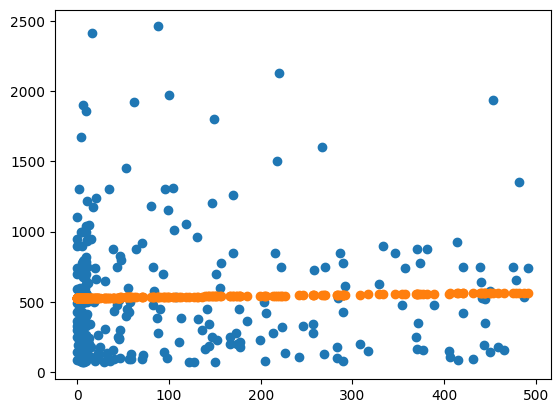

In [331]:
df['predicciones15'] = predicciones15
plt.scatter(df.Assists, df.Salary)
plt.scatter(df.Assists, df.predicciones15)

In [332]:
np.mean((df.predicciones15 - df.Salary)**2)

202603.10069507972

In [333]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.Assists,
                   y_pred = df.predicciones15)

191809.6457970305

In [334]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.Assists,
   y_pred = df.predicciones15)

-8.147582917753512

interpretaciones:

Bivariado	Errors

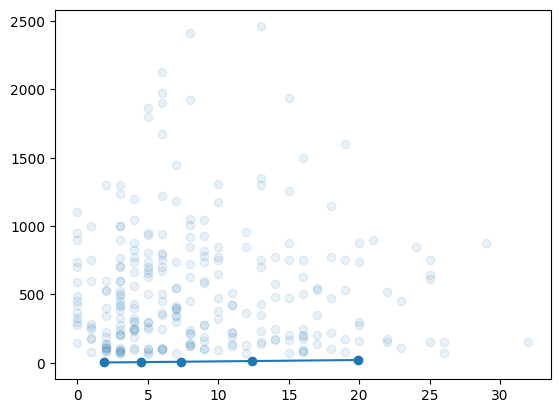

In [335]:
plt.scatter(df.Errors, df.Salary, alpha=0.1)
df['Errors_bin']= pd.qcut(df['Errors'], q=5, labels=False) + 1
grouped_Errors = df.groupby('Errors_bin').mean(numeric_only=True)
plt.plot(grouped_Errors.Errors.values, grouped_Errors.Errors.values, marker="o")

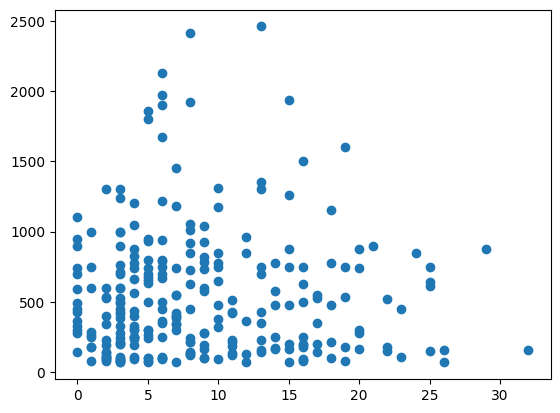

In [336]:
# Elimina los máximos y grafica
df = df[df.Errors != df.Salary.max()]
plt.scatter(df.Errors, df.Salary)

In [337]:
model16 = linear_model.LinearRegression()
X = df[['Errors']]
y = df[['Salary']]

# Fit the model to the data
model16.fit(X, y)  # This line is crucial

# Now you can access intercept_ and coef_
print(model16.intercept_)
print(model16.coef_)

[539.0948465]
[[-0.36877771]]


Ecuación:
$$Salary = 539.09 + (-0.36) * Errors$$

In [338]:
# Aplicando el modelo1
539.09 - 0.36 * X

,Errors
1,535.49
2,534.05
3,538.01
4,537.65
5,530.09
...,...
317,538.01
318,531.89
319,536.57
320,534.77


In [339]:
# Scikit learn ya nos ahorra esto, nos da lo mismo
# Utilizaremos la función predict
predicciones16 = model16.predict(X)
predicciones16

array([[535.40706938],
       [533.93195853],
       [537.98851337],
       [537.61973565],
       [529.87540369],
       [536.51340252],
       [535.77584709],
       [532.08806997],
       [539.0948465 ],
       [530.98173683],
       [535.03829167],
       [536.51340252],
       [536.88218023],
       [536.1446248 ],
       [535.40706938],
       [533.1944031 ],
       [538.35729108],
       [537.25095794],
       [538.35729108],
       [537.98851337],
       [533.93195853],
       [537.98851337],
       [537.98851337],
       [534.30073624],
       [533.1944031 ],
       [537.98851337],
       [537.61973565],
       [529.87540369],
       [537.25095794],
       [530.2441814 ],
       [536.88218023],
       [537.25095794],
       [538.72606879],
       [537.61973565],
       [532.45684768],
       [537.61973565],
       [535.77584709],
       [537.61973565],
       [537.98851337],
       [537.61973565],
       [537.25095794],
       [537.98851337],
       [538.35729108],
       [536

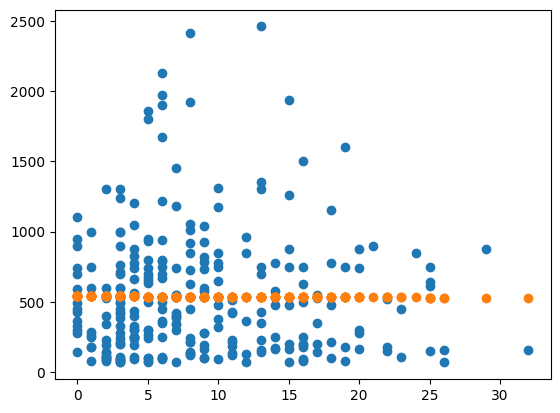

In [340]:
df['predicciones16'] = predicciones16
plt.scatter(df.Errors, df.Salary)
plt.scatter(df.Errors, df.predicciones16)

In [341]:
np.mean((df.predicciones16 - df.Salary)**2)

202728.35589100144

In [342]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true = df.Errors,
                   y_pred = df.predicciones16)

278161.2678406525

In [343]:
from sklearn.metrics import r2_score as r2
r2(y_true = df.Errors,
   y_pred = df.predicciones16)

-6396.325888660085

interpretaciones:

Las variables con mayor R^2 fueron:
- At bat con 0.14
- CHits con 0.53
- CRun con 0.66
- CRBI con 0.55

Estas son las 4 variables más significativas para poder predecir el Salario por lo que ahora haremos una regresión multiple con ellas.

In [366]:
categorical_cols = ['League', 'Division', 'NewLeague']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,League_N,Division_W,NewLeague_N
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,False,True,False


In [346]:
df.Salary.max()

2460.0

In [347]:
df = df[df.Salary != df.Salary.max()]

In [349]:
model_AtBat = linear_model.LinearRegression()
X_AtBat  = df[["AtBat"]]
target = "Salary"
y = df[target]
model_AtBat .fit(X_AtBat ,y)
predicitions_AtBat  = model_AtBat .predict(X_AtBat )
r2_score(y_pred = predicitions_AtBat , y_true=y)

0.15926373745740363

In [350]:
np.var(y)

189324.1281410801

In [351]:
np.var(y - predicitions_AtBat)

159171.6599024674

In [352]:
model_CHits = linear_model.LinearRegression()
X_CHits = df[["CHits"]]
model_CHits.fit(X_CHits,y)
predicitions_CHits = model_CHits.predict(X_CHits)
r2_score(y_pred = predicitions_CHits, y_true=y)

0.2985275832943459

In [356]:
model_CRuns = linear_model.LinearRegression()
X_CRuns = df[["CRuns"]]
model_CRuns.fit(X_CRuns,y)
predicitions_CRuns = model_CRuns.predict(X_CRuns)
r2_score(y_pred = predicitions_CRuns, y_true=y)

0.3128255049743315

In [357]:
model_CRBI = linear_model.LinearRegression()
X_CRBI = df[["CRBI"]]
model_CRBI.fit(X_CRBI,y)
predicitions_CRBI = model_CRBI.predict(X_CRBI)
r2_score(y_pred = predicitions_CRBI, y_true=y)

0.3099747256695129

In [358]:
X_multiple = df[["AtBat","CHits","CRuns","CRBI"]]
model_multiple = linear_model.LinearRegression()
model_multiple.fit(X_multiple,y)
predicitions_multiple = model_multiple.predict(X_multiple)
r2_score(y_pred = predicitions_multiple, y_true=y)

0.39798994400684007

El R^2 de la regresión multiple utilizando estas 4 variables es de 0.39
Sigue sin ser el mejor R^2, debemos seguir buscando como acercarnos al 1.

In [359]:
# Intercepto
model_multiple.intercept_

-37.14621365690425

In [360]:
# Coeficientes
model_multiple.coef_

array([ 0.83539376, -0.14915428,  0.55543008,  0.41630528])

$$Salary = \beta_0 + \beta_1 * x_1 + \beta_2* x_2 + \beta_3 * x_3 + \beta_4 * x_4$$

$$Salary = -37.14 + 0.8353 * AtBat - 0.1491 * CHits + 0.5554 * CRuns + 0.4163 * CRBI $$

In [372]:
X_multiple2 = df[["AtBat","CHits","CRuns","CRBI","League_N","Division_W","NewLeague_N"]]
model_multiple2 = linear_model.LinearRegression()
# Update y to match the rows in the modified df
y = df['Salary']  # Use the Salary column from the current df
model_multiple2.fit(X_multiple2,y)
predicitions_multiple2 = model_multiple2.predict(X_multiple2)
r2_score(y_pred = predicitions_multiple2, y_true=y)

0.4318707496236064

ahora utilizando las variables categoricas que convertimos a dummies podemos ver que nuestro R^2 incrementa a 0.43


In [377]:
# Intercepto
model_multiple2.intercept_

2.2478354736823576

In [378]:
# Coeficientes
model_multiple2.coef_

array([   0.85037522,   -0.17175266,    0.47636342,    0.56948727,
         56.07775695, -141.73172281])

$$Salary = \beta_0 + \beta_1 * x_1 + \beta_2* x_2 + \beta_3 * x_3 + \beta_4 * x_4 + \beta_5 * x_5 + \beta_6 * x_6$$

$$Salary = 2.2478 + 0.8503 * AtBat - 0.1717 * CHits + 0.4763 * CRuns + 0.5694 * CRBI + 56.077 * League_N - 141.73 * Division_W $$

In [379]:
### Verific los NA's
X =df.copy()
X.drop(target, axis=1, inplace=True)
X = pd.get_dummies(X)


In [380]:
df.isna().sum()

,0
AtBat,0
Hits,0
HmRun,0
Runs,0
RBI,0
Walks,0
Years,0
CAtBat,0
CHits,0
CHmRun,0


In [382]:
X =df.copy()
X.drop(target, axis=1, inplace=True)
X = pd.get_dummies(X)

for column in X.select_dtypes(include=np.number).columns:
    X[column] = X[column].fillna(X[column].mean())

model_todo = linear_model.LinearRegression().fit(X,y)
predicciones_todo = model_todo.predict(X)
r2_score(y_pred = predicciones_todo, y_true=y)

0.5461158619125321

In [383]:
coeficientes = pd.DataFrame({
    "names": X.keys,
    "coeficientes": model_todo.coef_
})

In [384]:
calibracion = pd.DataFrame({
    "predicciones": predicciones_todo,
    "real": y
})

In [385]:
calibracion["bins"] = pd.qcut(calibracion["predicciones"],  q = 10, labels = False) + 1
grouped_calibracion = calibracion.groupby("bins").mean()

In [386]:
grouped_calibracion["error"] = (grouped_calibracion.predicciones - grouped_calibracion.real) / grouped_calibracion.predicciones
grouped_calibracion

,predicciones,real,error
bins,,,
1,128.280934,154.691370,-0.205880
2,222.174103,324.461538,-0.460393
3,285.695073,315.788462,-0.105334
4,347.471747,304.615385,0.123338
5,418.575695,339.419778,0.189108
6,507.837810,459.865385,0.094464
7,609.825815,617.083308,-0.011901
8,717.117276,796.634615,-0.110885
9,858.841755,785.672154,0.085196


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

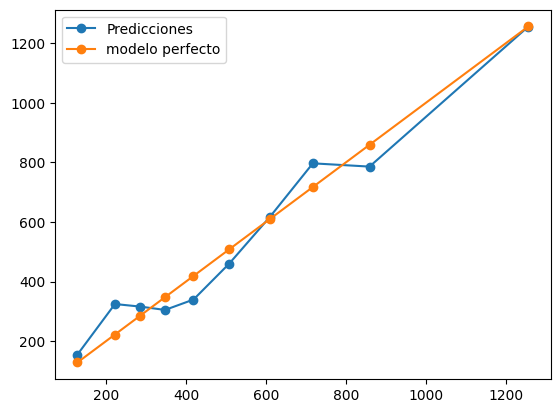

In [425]:
plt.plot(grouped_calibracion.predicciones.values, grouped_calibracion.real.values,
         marker="o", label = "Predicciones")
plt.plot(grouped_calibracion.predicciones.values, grouped_calibracion.predicciones.values,
         marker = "o", label = "modelo perfecto")
plt.legend()
plt

# NOTAS Y OBSERVACIONES HASTA EL MOMENTO:
  
### **Regresiones Lineales Univariadas y Multiples**  
Analisando la relación de cada variable con el Salario podemos ver de manera más clara culaes son las más significativas. La variable AtBat a pesar de tener un R^2 de 0.14 aumento el R^2 de la regresión multiple, intente quitar la varible y este bajó. Sin embargo, definitivamente las variables que mejor nos ayudan a predecir son CHits y CRuns con R^2 de 0.53 y 0.66

Utilizando una Regresión Lineal Simple el mejor R^2 que encontré fue utilizando estas 4 varibles (AtBat, CHits, CRuns, CRBI) y añadiendo también las varibles categoricas convertidas a dummies. Sin las categóricas el R^2 era de 0.39 y ya con ellas es de 0.43. Esto significa que las varibales categoricas si tienen información relrevate para hacer la predicción del salario de un jugador.

Sin embargo, un R^2 de 0.43 sigue siendo no muy bueno, lo que significa que el modelo solo explica el 43% de la variabilidad en los salarios.  

Para el modelo final utilicé todas las características y rellené los Nans con el promedio de su columna. Haciendo esto obtuve un R^2 de 0.54

Con la gráfica de Calibración podemos ver que la predicción no está muy ajustada a los valores reales y nos indica que debemos de intentar con otro tipo de Regresión.


# Regresión Polinomial

In [426]:
import pandas as pd
from sklearn import linear_model
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

target = 'Salary'
df = pd.get_dummies(df)


In [427]:
# Bivariado de CRun
df['CRuns_bin'] = pd.qcut(df['CRuns'], q=10, labels=False) + 1
bivariado_CRuns = df.groupby('CRuns_bin').mean()

para esta regresión utilizamos la varible CRun porque en su analisis Bivariado era la que mayor R^2 tenía.

In [428]:
# Regresion lineal simple temp
X = df[['CRuns']]
y = df[target]
model = linear_model.LinearRegression().fit(X, y)
df['predicciones_simple'] = model.predict(X)

In [431]:
degree = 2
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)  # Transformar X a características polinómicas

# Ajustar el modelo de regresión lineal
model = linear_model.LinearRegression()
model.fit(X_poly, y)
predicciones_polinomio2 = model.predict(X_poly)

In [432]:
r2_score(y_pred=predicciones_polinomio2, y_true=y)

0.3961055454841711

In [435]:
# Regresion polinomial grado 3
degree = 3
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)  # Transformar X a características polinómicas

# Ajustar el modelo de regresión lineal
model = linear_model.LinearRegression()
model.fit(X_poly, y)
predicciones_polinomio3 = model.predict(X_poly)

In [436]:
r2_score(y_pred=predicciones_polinomio3, y_true=y)

0.4048549969780668

In [437]:
# Regresion polinomial grado 4
degree = 4
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)  # Transformar X a características polinómicas

# Ajustar el modelo de regresión lineal
model = linear_model.LinearRegression()
model.fit(X_poly, y)
predicciones_polinomio4 = model.predict(X_poly)

In [438]:
r2_score(y_pred=predicciones_polinomio4, y_true=y)

0.40502311780392053

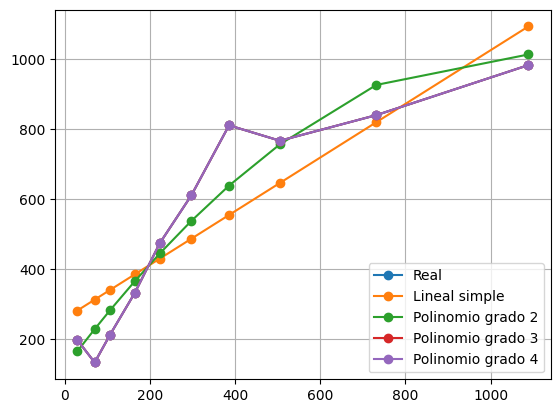

In [451]:
# Bivariado vs regresion lineal
plt.plot(bivariado_CRuns.CRuns.values,
        bivariado_CRuns.Salary.values, marker="o", label="Real")

plt.plot(bivariado_CRuns.CRuns.values,
        bivariado_CRuns.predicciones_simple.values, marker="o", label="Lineal simple")

plt.plot(bivariado_CRuns.CRuns.values,
        bivariado_CRuns.predicciones_polinimio2.values, marker="o", label="Polinomio grado 2")


plt.plot(bivariado_CRuns.CRuns.values,
        bivariado_CRuns.predicciones_polinimio3.values, marker="o", label="Polinomio grado 3")

plt.plot(bivariado_CRuns.CRuns.values,
        bivariado_CRuns.predicciones_polinimio4.values, marker="o", label="Polinomio grado 4")



plt.legend()
plt.grid()

En este caso podemos ver que la regresión polinomial no fue mejor que la lineal multiple  y que al incrementar el grado del polinomio la predicción empeora. Lo intentaremos con otra regresión.

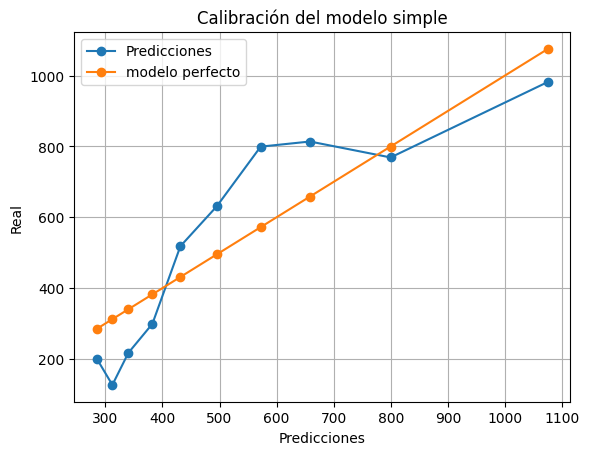

In [452]:
# Crear un DataFrame para calibración
calibracion = pd.DataFrame({
    'predicciones': df['predicciones_simple'],
    'real': df['Salary']
})

# Crear categorías (bins) utilizando pd.qcut
calibracion['bins'] = pd.qcut(calibracion['predicciones'], q=10, labels=False) + 1

# Mostrar el DataFrame de calibración
grouped_calibracion = calibracion.groupby("bins").mean()

plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.real.values, marker = 'o', label = 'Predicciones')
plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.predicciones.values, marker = 'o', label = 'modelo perfecto')
plt.legend()
plt.grid()
plt.xlabel("Predicciones")
plt.ylabel("Real")
plt.title("Calibración del modelo simple")
plt.show()

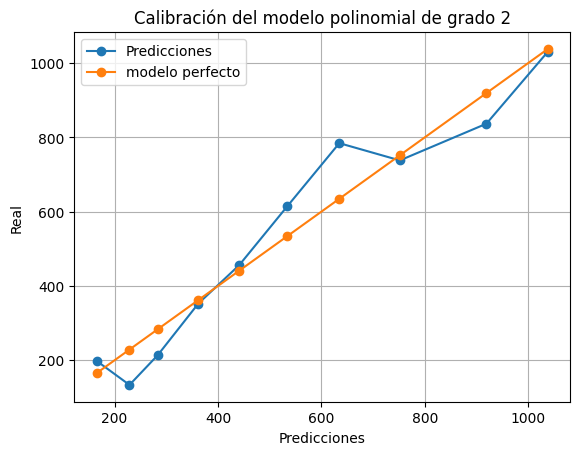

In [454]:
# Crear un DataFrame para calibración
calibracion = pd.DataFrame({
    'predicciones': df['predicciones_polinomio2'],
    'real': df['Salary']
})

# Crear categorías (bins) utilizando pd.qcut
calibracion['bins'] = pd.qcut(calibracion['predicciones'], q=10, labels=False) + 1

# Mostrar el DataFrame de calibración
grouped_calibracion = calibracion.groupby("bins").mean()

plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.real.values, marker = 'o', label = 'Predicciones')
plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.predicciones.values, marker = 'o', label = 'modelo perfecto')
plt.legend()
plt.grid()
plt.xlabel("Predicciones")
plt.ylabel("Real")
plt.title("Calibración del modelo polinomial de grado 2")
plt.show()


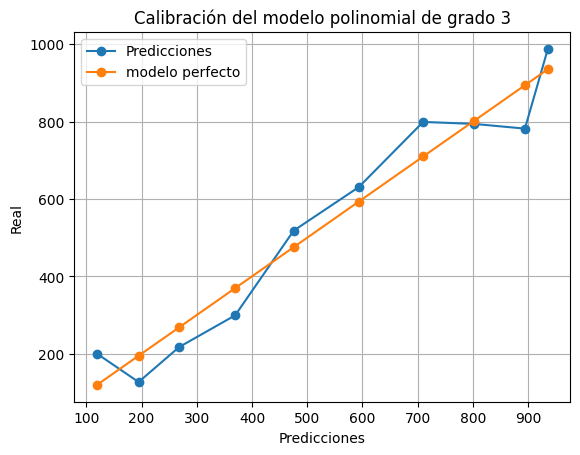

In [458]:
# Crear un DataFrame para calibración
calibracion = pd.DataFrame({
    'predicciones': predicciones_polinomio3,
    'real': df['Salary']
})

# Crear categorías (bins) utilizando pd.qcut
calibracion['bins'] = pd.qcut(calibracion['predicciones'], q=10, labels=False) + 1

# Mostrar el DataFrame de calibración
grouped_calibracion = calibracion.groupby("bins").mean()

plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.real.values, marker = 'o', label = 'Predicciones')
plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.predicciones.values, marker = 'o', label = 'modelo perfecto')
plt.legend()
plt.grid()
plt.xlabel("Predicciones")
plt.ylabel("Real")
plt.title("Calibración del modelo polinomial de grado 3")
plt.show()

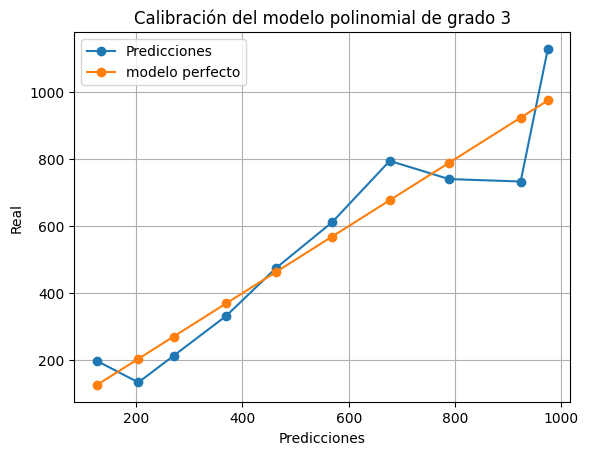

In [459]:
# Crear un DataFrame para calibración
calibracion = pd.DataFrame({
    'predicciones': predicciones_polinomio4,
    'real': df['Salary']
})

# Crear categorías (bins) utilizando pd.qcut
calibracion['bins'] = pd.qcut(calibracion['predicciones'], q=10, labels=False) + 1

# Mostrar el DataFrame de calibración
grouped_calibracion = calibracion.groupby("bins").mean()

plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.real.values, marker = 'o', label = 'Predicciones')
plt.plot(grouped_calibracion.predicciones.values,
         grouped_calibracion.predicciones.values, marker = 'o', label = 'modelo perfecto')
plt.legend()
plt.grid()
plt.xlabel("Predicciones")
plt.ylabel("Real")
plt.title("Calibración del modelo polinomial de grado 3")
plt.show()

Con estas gráficas de calibración podemos ver que todavía necesitamos mejorar el modeo e intentar otra cosa.

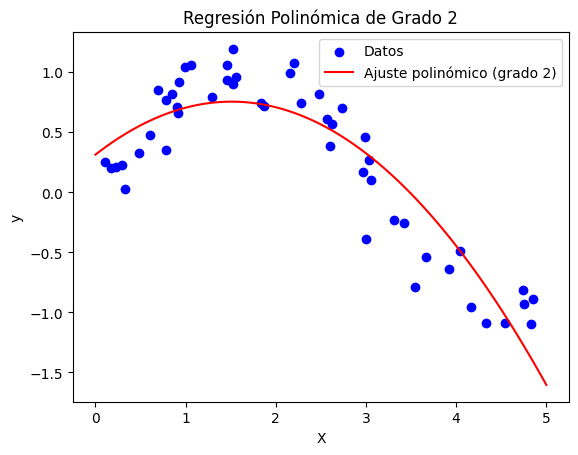

In [460]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Generar datos simulados
np.random.seed(42)
X = np.sort(5 * np.random.rand(50, 1), axis=0)  # Valores entre 0 y 5
y = np.sin(X).ravel() + np.random.normal(scale=0.2, size=X.shape[0])  # Seno con ruido

# Crear la transformación polinómica de grado 2
degree = 2
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)  # Transformar X a características polinómicas

# Ajustar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_poly, y)

# Predecir valores
X_fit = np.linspace(0, 5, 100).reshape(-1, 1)
X_fit_poly = poly_features.transform(X_fit)  # Transformar X_fit a características polinómicas
y_fit = model.predict(X_fit_poly)

# Graficar los resultados
plt.scatter(X, y, color="blue", label="Datos")
plt.plot(X_fit, y_fit, color="red", label="Ajuste polinómico (grado 2)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Regresión Polinómica de Grado 2")
plt.show()

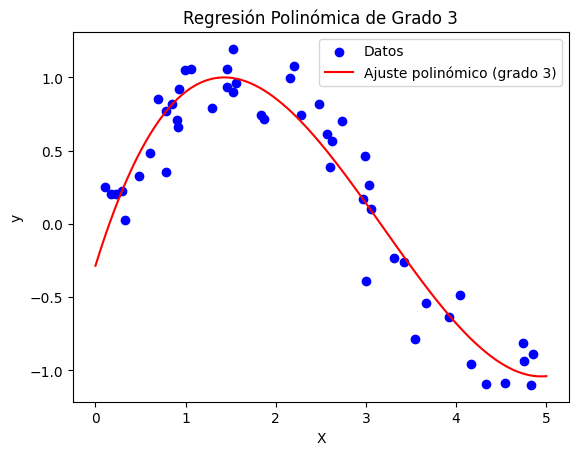

In [461]:
# Generar datos simulados
np.random.seed(42)
X = np.sort(5 * np.random.rand(50, 1), axis=0)  # Valores entre 0 y 5
y = np.sin(X).ravel() + np.random.normal(scale=0.2, size=X.shape[0])  # Seno con ruido

# Crear la transformación polinómica de grado 3
degree = 3
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)  # Transformar X a características polinómicas

# Ajustar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_poly, y)

# Predecir valores
X_fit = np.linspace(0, 5, 100).reshape(-1, 1)
X_fit_poly = poly_features.transform(X_fit)  # Transformar X_fit a características polinómicas
y_fit = model.predict(X_fit_poly)

# Graficar los resultados
plt.scatter(X, y, color="blue", label="Datos")
plt.plot(X_fit, y_fit, color="red", label="Ajuste polinómico (grado 3)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Regresión Polinómica de Grado 3")
plt.show()

# AB Test para Cruns

In [462]:
from scipy import stats

def AB_test(test, control):
    # Mu
    mu_test = test.mean()
    mu_control = control.mean()

    # SE
    se_test = test.sem()
    se_control = control.sem()

    # Differences
    mu_diff = mu_control - mu_test
    se_diff = np.sqrt((test.var() / len(test)) + (control.var() / len(control)))

    # Z score and p value
    z = mu_diff / se_diff

    p_value = stats.norm.cdf(z)

    print(f"Variable test entre {mu_test -2*se_test} y {mu_test + 2*se_test}")
    print(f"Variable control entre {mu_control -2*se_control} y {mu_control + 2*se_control}")
    print(f"Z score {z}")
    print(f"P value {p_value}")


    return mu_diff, se_diff


mu_diff, se_diff = AB_test(df['Salary'], df['CRuns'])


print(f"Intervalo de confianza del efecto causal entre {mu_diff -2*se_diff} y {mu_diff + 2*se_diff}")


Variable test entre 480.2915430767928 y 591.5602211817622
Variable control entre 320.3753748066916 y 402.06568983209166
Z score -5.062590680416021
P value 2.0679861400567147e-07
Intervalo de confianza del efecto causal entre -243.72351099985173 y -105.68718861992004


AB Test para CRBI

In [463]:
from scipy import stats

def AB_test(test, control):
    # Mu
    mu_test = test.mean()
    mu_control = control.mean()

    # SE
    se_test = test.sem()
    se_control = control.sem()

    # Differences
    mu_diff = mu_control - mu_test
    se_diff = np.sqrt((test.var() / len(test)) + (control.var() / len(control)))

    # Z score and p value
    z = mu_diff / se_diff

    p_value = stats.norm.cdf(z)

    print(f"Variable test entre {mu_test -2*se_test} y {mu_test + 2*se_test}")
    print(f"Variable control entre {mu_control -2*se_control} y {mu_control + 2*se_control}")
    print(f"Z score {z}")
    print(f"P value {p_value}")


    return mu_diff, se_diff



mu_diff, se_diff = AB_test(df['Salary'], df['CRBI'])


print(f"Intervalo de confianza del efecto causal entre {mu_diff -2*se_diff} y {mu_diff + 2*se_diff}")


Variable test entre 480.2915430767928 y 591.5602211817622
Variable control entre 290.5388416956208 y 370.29766020551983
Z score -6.004513164604484
P value 9.595342208534364e-10
Intervalo de confianza del efecto causal entre -273.9586864249967 y -137.05657593241764


In [464]:
from scipy import stats

def AB_test(test, control):
    # Mu
    mu_test = test.mean()
    mu_control = control.mean()

    # SE
    se_test = test.sem()
    se_control = control.sem()

    # Differences
    mu_diff = mu_control - mu_test
    se_diff = np.sqrt((test.var() / len(test)) + (control.var() / len(control)))

    # Z score and p value
    z = mu_diff / se_diff

    p_value = stats.norm.cdf(z)

    print(f"Variable test entre {mu_test -2*se_test} y {mu_test + 2*se_test}")
    print(f"Variable control entre {mu_control -2*se_control} y {mu_control + 2*se_control}")
    print(f"Z score {z}")
    print(f"P value {p_value}")


    return mu_diff, se_diff



mu_diff, se_diff = AB_test(df['Salary'], df['League_N'])


print(f"Intervalo de confianza del efecto causal entre {mu_diff -2*se_diff} y {mu_diff + 2*se_diff}")


Variable test entre 480.2915430767928 y 591.5602211817622
Variable control entre 0.4098032477484055 y 0.5331625317192751
Z score -19.24904939243263
P value 7.18884383515138e-83
Intervalo de confianza del efecto causal entre -591.0887724829358 y -479.82002599615157


In [465]:
from scipy import stats

def AB_test(test, control):
    # Mu
    mu_test = test.mean()
    mu_control = control.mean()

    # SE
    se_test = test.sem()
    se_control = control.sem()

    # Differences
    mu_diff = mu_control - mu_test
    se_diff = np.sqrt((test.var() / len(test)) + (control.var() / len(control)))

    # Z score and p value
    z = mu_diff / se_diff

    p_value = stats.norm.cdf(z)

    print(f"Variable test entre {mu_test -2*se_test} y {mu_test + 2*se_test}")
    print(f"Variable control entre {mu_control -2*se_control} y {mu_control + 2*se_control}")
    print(f"Z score {z}")
    print(f"P value {p_value}")


    return mu_diff, se_diff



mu_diff, se_diff = AB_test(df['Salary'], df['Division_W'])


print(f"Intervalo de confianza del efecto causal entre {mu_diff -2*se_diff} y {mu_diff + 2*se_diff}")


Variable test entre 480.2915430767928 y 591.5602211817622
Variable control entre 0.44773666283042723 y 0.5712747440136793
Z score -19.24768247604595
P value 7.38102044125939e-83
Intervalo de confianza del efecto causal entre -591.0507497684321 y -479.78200308327877


In [466]:
from scipy import stats

def AB_test(test, control):
    # Mu
    mu_test = test.mean()
    mu_control = control.mean()

    # SE
    se_test = test.sem()
    se_control = control.sem()

    # Differences
    mu_diff = mu_control - mu_test
    se_diff = np.sqrt((test.var() / len(test)) + (control.var() / len(control)))

    # Z score and p value
    z = mu_diff / se_diff

    p_value = stats.norm.cdf(z)

    print(f"Variable test entre {mu_test -2*se_test} y {mu_test + 2*se_test}")
    print(f"Variable control entre {mu_control -2*se_control} y {mu_control + 2*se_control}")
    print(f"Z score {z}")
    print(f"P value {p_value}")


    return mu_diff, se_diff



mu_diff, se_diff = AB_test(df['Salary'], df['NewLeague_N'])


print(f"Intervalo de confianza del efecto causal entre {mu_diff -2*se_diff} y {mu_diff + 2*se_diff}")


Variable test entre 480.2915430767928 y 591.5602211817622
Variable control entre 0.40225955014900916 y 0.5254971038433863
Z score -19.249322792182973
P value 7.15100929446389e-83
Intervalo de confianza del efecto causal entre -591.0963769782279 y -479.82763062633467


# STATSMODEL

In [467]:
import statsmodels.formula.api as smf

result = smf.ols('Salary ~  CRuns + CRBI + League_N + Division_W + NewLeague_N', data=df).fit()
result.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,337.1982,47.252,7.136,0.000,244.148,430.248
League_N[T.True],0.8400,89.205,0.009,0.992,-174.826,176.506
Division_W[T.True],-157.4760,45.150,-3.488,0.001,-246.387,-68.565
NewLeague_N[T.True],15.1594,89.222,0.170,0.865,-160.541,190.860
CRuns,0.2821,0.210,1.342,0.181,-0.132,0.696
CRBI,0.5134,0.215,2.389,0.018,0.090,0.937


Ambos con el AB test y con el statsmodel podemos ver que variables son más significativas. Aquí podemos ver que la variable de League_N es cercana a 1 lo que significa que no podemos rechazar la hipótesis nula es decir que no hay evidencia suficiente para saber si esta variable es significativa. Lo mismo sucede con la varible NewLeague. Por otro lado podemos ver que lo mejor sería dejar las varibales Division_W, CRuns, y CRBI.

# Ridge Regresión

In [478]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error

data['Salary'] = data['Salary'].fillna(data['Salary'].mean())

# Selección de características y target

data = data.dropna(subset=['Salary'])
X = data.drop(columns=['Salary', 'CRBI', 'Division'])
X['CRuns'] = X.CRuns.fillna(X.CRuns.mean())


y = data['Salary']


X = pd.get_dummies(X, drop_first=True)

# Escalado de las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [479]:
# Modelo de Regresión Lineal
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Modelo de Ridge con penalización (λ = 10)
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train, y_train)

# Predicciones
y_pred_linear = linear_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)

# Métricas de error
mse_linear = mean_squared_error(y_test, y_pred_linear)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f"MSE de Regresión Lineal: {mse_linear:.2f}")
print(f"MSE de Ridge Regression (λ=10): {mse_ridge:.2f}")

MSE de Regresión Lineal: 129372.27
MSE de Ridge Regression (λ=10): 120565.82


In [480]:
# Modelo de Regresión Lineal
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Modelo de Ridge con penalización (λ = 10)
ridge_model = Ridge(alpha=120)
ridge_model.fit(X_train, y_train)

# Predicciones
y_pred_linear = linear_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)

# Métricas de error
mse_linear = mean_squared_error(y_test, y_pred_linear)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

print(f"MSE de Regresión Lineal: {mse_linear:.2f}")
print(f"MSE de Ridge Regression (λ=10): {mse_ridge:.2f}")


MSE de Regresión Lineal: 129372.27
MSE de Ridge Regression (λ=10): 120354.47


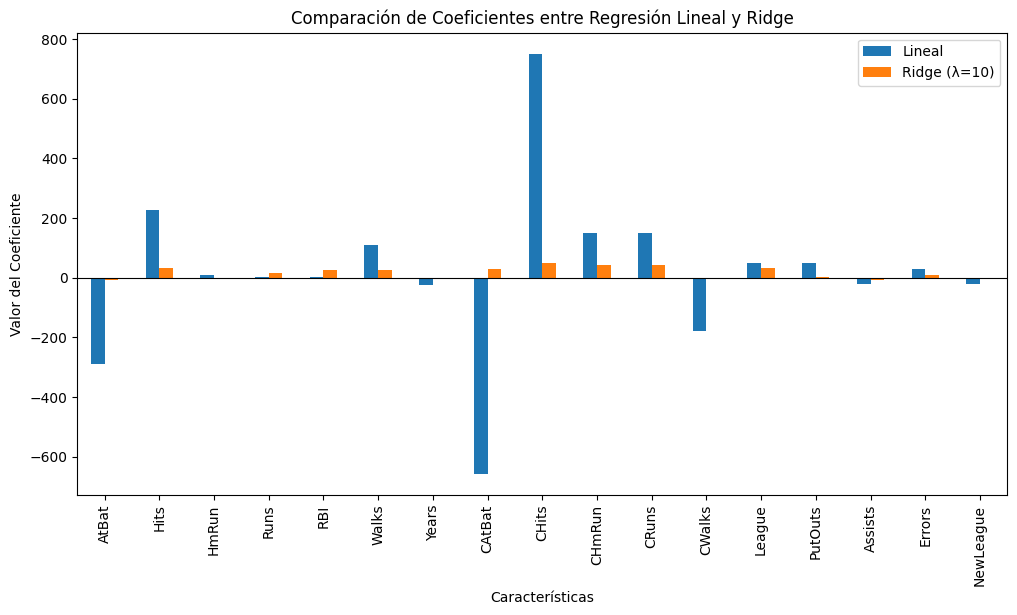

In [481]:
# Coeficientes de los modelos
coef_linear = linear_model.coef_
coef_ridge = ridge_model.coef_

# Crear un DataFrame para comparar coeficientes
coef_df = pd.DataFrame({
    'Características': data.drop(columns=['Salary', 'CRBI', 'Division']).columns,
    'Lineal': coef_linear,
    'Ridge (λ=10)': coef_ridge
})

# Visualización de los coeficientes
coef_df.set_index('Características').plot(kind='bar', figsize=(12, 6))
plt.title('Comparación de Coeficientes entre Regresión Lineal y Ridge')
plt.ylabel('Valor del Coeficiente')
plt.xlabel('Características')
plt.axhline(0, color='black', linewidth=0.8)
plt.legend()
plt.show()


# observaciones:

Esta gráfica muestra cómo cada variable influye en el salario, comparando los modelos de regresión lineal y Ridge. La regresión Ridge reduce la magnitud de los coeficientes debido a la regularización L2, así estamos evitando un sobreajuste.  

Algunas variables mantienen coeficientes similares en los 2 modelos, lo que indica que su importancia es estable. Pero, otras se reducen en Ridge, lo que puede decir que la regresión lineal podría estar sobrevalorando ciertas variables.  

El MSE menor es el de la regresión Ridge lo que significa que es la que se ajusta mejor.

# KNN

In [486]:
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.metrics import r2_score


In [491]:
df = pd.read_csv('Hitters.csv')
df = pd.get_dummies(df)
df['Salary'] = df['Salary'].fillna(df.Salary.mean())

In [492]:
X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Normalizar las características (KNN es sensible a escalas)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [493]:
nn = []
r2 = []
for i in range(2, 50):
    nn.append(i)
    neigh = KNeighborsRegressor(n_neighbors=i)
    neigh.fit(X_train, y_train)
    predicciones = neigh.predict(X_test)
    r2.append(r2_score(y_pred=predicciones, y_true=y_test))

El mejor valor de k es: 2
El mejor valor de R^2 es: 0.44851653370033284


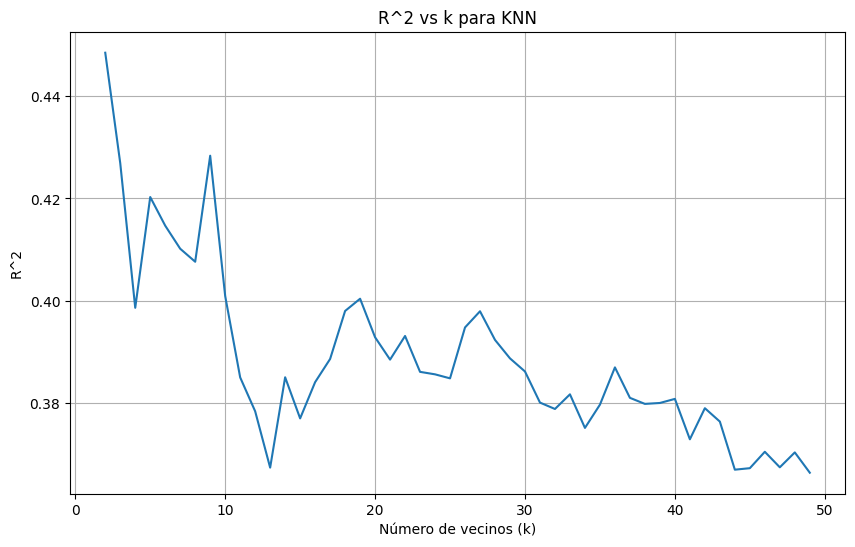

In [495]:
best_k = nn[np.argmax(r2)]
print(f"El mejor valor de k es: {best_k}")
print(f"El mejor valor de R^2 es: {np.max(r2)}")

# Graficar el R^2 vs k
plt.figure(figsize=(10, 6))
plt.plot(nn, r2)
plt.xlabel("Número de vecinos (k)")
plt.ylabel("R^2")
plt.title("R^2 vs k para KNN")
plt.grid(True)
plt.show()

A pesar de intentar mejor el R^2 con diferetes modelos el mejor es 0.44 Esto sigue sin ser un buen indicador, tendría que investigar más a fondo como poder mejorarlo.